## **Problema 1 - Clasificación: Detección de Fatiga Muscular en Ciclismo**

### **Equipo**

- Juan José Escobar
- Juan David Salas

### **Dataset**

- **Nombre:** Muscle Fatigue Cycling
- **Fuente:** HuggingFace - [YominE/Muscle_Fatigue_Cycling](https://huggingface.co/datasets/YominE/Muscle_Fatigue_Cycling)
- **Descripción:** Señales de electromiografía (EMG) registradas en 8 músculos de la pierna dominante de sujetos realizando sprints en bicicleta. El target indica el estado muscular del sujeto durante la prueba (condición normal vs. desgaste muscular).



### **1. Análisis Preliminar del Problema**

#### 1.1 Importación de librerías

Primero, importamos todas las librerías necesarias para el proyecto.

In [256]:
# Manipulación de datos
import pandas as pd
import numpy as np
import warnings

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Procesamiento de señales
from scipy.signal import welch

# Preprocesamiento y modelos
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight

# Manejo de desbalance de clases
try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'imbalanced-learn', '-q'])
    from imblearn.over_sampling import SMOTE

# XGBoost
try:
    from xgboost import XGBClassifier
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'xgboost', '-q'])
    from xgboost import XGBClassifier

# Modelos de clasificación
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

# Métricas de evaluación
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)


# Configuración de visualización
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore', message='X has feature names')
warnings.filterwarnings('ignore', message='X does not have valid feature names')

print("Librerías importadas correctamente.")


Librerías importadas correctamente.


#### **1.2 Carga de los Datasets originales**

Cargamos los 3 archivos CSV correspondientes a los pacientes.

In [257]:
# Rutas de los archivos
rutas_csv = [
    'data/Patient1.csv',
    'data/Patient2.csv', 
    'data/Patient3.csv'
]

# Cargar cada dataset en un DataFrame
dataframes_originales = []
for ruta in rutas_csv:
    df = pd.read_csv(ruta)
    print(f"Archivo: {ruta} - Dimensiones: {df.shape}")
    dataframes_originales.append(df)

# Concatenar todos los DataFrames en uno solo
df_original = pd.concat(dataframes_originales, ignore_index=True)
print(f"\nDataset combinado - Dimensiones totales: {df_original.shape}")
print(f"Columnas disponibles: {df_original.columns.tolist()}")

Archivo: data/Patient1.csv - Dimensiones: (686525, 10)
Archivo: data/Patient2.csv - Dimensiones: (1741599, 10)
Archivo: data/Patient3.csv - Dimensiones: (574013, 10)

Dataset combinado - Dimensiones totales: (3002137, 10)
Columnas disponibles: ['Time', 'Right Rectus femoris', 'Left Gluteus maximus', 'Left Gastrocnemius medialis', 'Left Semitendinosus', 'Left Biceps femoris caput longus', 'Right Vastus medialis', 'Right Tibialis anterior', 'Left Gastrocnemius lateralis', 'Target']


#### **1.3 Preprocesamiento del Target**

Transformamos las etiquetas para tener solo 2 clases: Normal (0) y Desgaste muscular (1). Las etiquetas con valor 2 se convierten a 1.

In [258]:
# Ver distribución original del target
print("Distribución original del target:")
print(df_original['Target'].value_counts())
print(f"Porcentajes:\n{df_original['Target'].value_counts(normalize=True) * 100}")

# Mapear valores: 2 -> 1 (desgaste), mantener 0 como normal
df_original['Target'] = df_original['Target'].replace({2: 1})

# Verificar la nueva distribución
print("\nDistribución después del mapeo:")
print(df_original['Target'].value_counts())
print(f"Porcentajes:\n{df_original['Target'].value_counts(normalize=True) * 100}")

# Renombrar la columna para mayor claridad
df_original.rename(columns={'Target': 'fatiga'}, inplace=True)

Distribución original del target:
Target
0    2127600
1     631200
2     243337
Name: count, dtype: int64
Porcentajes:
Target
0    70.869517
1    21.025023
2     8.105460
Name: proportion, dtype: float64

Distribución después del mapeo:
Target
0    2127600
1     874537
Name: count, dtype: int64
Porcentajes:
Target
0    70.869517
1    29.130483
Name: proportion, dtype: float64


#### **1.4 Clasificación de Características**

Analizamos los tipos de datos presentes en el dataset original.

In [259]:
# Información general del dataset
print("Información del dataset:")
print(df_original.info())

# Muestra pequeña del dataset
print("\nMuestra del dataset")
print(df_original.head())

# Mostrar estadísticas descriptivas básicas
print("\nEstadísticas descriptivas:")
print(df_original.describe())

Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 3002137 entries, 0 to 3002136
Data columns (total 10 columns):
 #   Column                            Dtype  
---  ------                            -----  
 0   Time                              float64
 1   Right Rectus femoris              float64
 2   Left Gluteus maximus              float64
 3   Left Gastrocnemius medialis       float64
 4   Left Semitendinosus               float64
 5   Left Biceps femoris caput longus  float64
 6   Right Vastus medialis             float64
 7   Right Tibialis anterior           float64
 8   Left Gastrocnemius lateralis      float64
 9   fatiga                            int64  
dtypes: float64(9), int64(1)
memory usage: 229.0 MB
None

Muestra del dataset
    Time  Right Rectus femoris  Left Gluteus maximus  \
0  0.000             -0.000264             -0.000015   
1  0.001             -0.001002             -0.000045   
2  0.002             -0.002173             -0.000034   
3  0.00

**Clasificación de Variables:**

1. Variable temporal:
    - Time: Numérica continua (tiempo en segundos)

2. Variables de las señales EMG:
    - Right Rectus femoris: Numérica continua (voltaje)
    - Left Gluteus maximus: Numérica continua (voltaje)
    - Left Gastrocnemius medialis: Numérica continua (voltaje)
    - Left Semitendinosus: Numérica continua (voltaje)
    - Left Biceps femoris caput longus : Numérica continua (voltaje)
    - Right Vastus medialis: Numérica continua (voltaje)
    - Right Tibialis anterior: Numérica continua (voltaje)
    - Left Gastrocnemius lateralis: Numérica continua (voltaje)

3. Variable Target:
    - fatiga: Numérica binaria (0 = Normal, 1 = Desgaste muscular)

### **2. Extracción de Características (Feature Engineering)**

#### **2.1 Definición de Funciones para Extracción de Características**

Las características extraídas combinan información del **dominio del tiempo** y del **dominio de la frecuencia** porque la fatiga muscular se manifiesta en ambos aspectos de la señal EMG:

- **Dominio del tiempo**: Refleja cambios en la **amplitud** y **patrón de activación** muscular.
- **Dominio de la frecuencia**: Refleja cambios en la **velocidad de conducción** de las fibras musculares y el espectro de potencia.

A continuación, se detalla cada característica, su relevancia fisiológica y su posible redundancia:

| Característica | Dominio | Relevancia Fisiológica | Ventaja | ¿Redundante? |
|---|---|---|---|---|
| **RMS (Root Mean Square)** | Tiempo | Mide la **amplitud efectiva** de la señal. Con fatiga, aumenta el reclutamiento de unidades motoras para mantener la fuerza, incrementando el RMS. | Es la medida de amplitud más robusta y común en análisis EMG. | No es redundante; captura información única de amplitud efectiva. |
| **Varianza** | Tiempo | Indica la **potencia** de la señal y su dispersión. Relacionada con la energía muscular desarrollada. | Fácil de calcular, complementa al RMS. | **Correlación muy alta con RMS**. Ambos miden amplitud/potencia. |
| **ZCR (Zero Crossing Rate)** | Tiempo | Número de veces que la señal cruza el cero. Relacionado con la **frecuencia dominante** de la señal. Con fatiga, la frecuencia disminuye, reduciendo el ZCR. | Aproximación rápida de la frecuencia sin necesidad de transformada de Fourier. | No es redundante; es una medida de frecuencia en el dominio del tiempo. |
| **MAV (Mean Absolute Value)** | Tiempo | Promedio del valor absoluto. Similar al RMS pero menos sensible a picos extremos. | Más robusto al ruido impulsivo que el RMS. | **Sí puede ser redundante con RMS** (correlación > 0.98). Miden lo mismo con diferente énfasis. |
| **Potencia Espectral Total** | Frecuencia | Energía total de la señal en el dominio de la frecuencia. Por el teorema de Parseval, es equivalente a la varianza en tiempo. | Útil para normalizar otras características espectrales. | **Sí puede ser redundante con la varianza**. Es el equivalente a la varianza en el dominio de la frecuencia (teorema de Parseval). |
| **Frecuencia Media** | Frecuencia | Promedio ponderado de frecuencias (centroide espectral). Con fatiga, el espectro se desplaza a bajas frecuencias, disminuyendo este valor. | Menos sensible a ruido que la frecuencia mediana. | No es redundante; captura el centroide espectral. |
| **Frecuencia Mediana** | Frecuencia | Frecuencia que divide el espectro de potencias en dos mitades iguales. | **Es el indicador MÁS ROBUSTO de fatiga muscular** en la literatura especializada. Altamente sensible a cambios espectrales. | No es redundante; es el estándar para detección de fatiga. |

#### Análisis de Redundancia y su Impacto

Del análisis de correlaciones que se presentará en la sección 3.4, observamos que ciertas características son prácticamente equivalentes:

| Grupo Redundante | Explicación | Impacto en Modelos |
|---|---|---|
| RMS <=> MAV | Ambos miden amplitud. MAV es la media absoluta, RMS es la raíz cuadrática media. | **Redundancia alta**. En modelos lineales causa multicolinealidad; en tree-based models es menos problemática. |
| RMS <=> Varianza | La varianza es el cuadrado del RMS si la señal tiene media cero. | **Redundancia moderada-alta**. Similar al caso anterior. |
| Potencia Espectral <=> Varianza | Teorema de Parseval: la potencia en frecuencia es igual a la varianza en tiempo cuando la señal tiene media cero. | **Redundancia teórica**. Son la misma información en dominios diferentes. |
| Frec. Media <=> Frec. Mediana | Ambas miden la tendencia central del espectro; se mueven juntas ante desplazamientos espectrales. | **Redundancia esperada**, pero ambas se mantienen por su relevancia clínica. |

#### Decisión sobre Mantener Características Redundantes

A pesar de la redundancia identificada, se mantendrán todas las características por las siguientes razones:

1. **Robustez de los modelos seleccionados**: Random Forest, Gradient Boosting y DNN son robustos a la multicolinealidad. Los árboles de decisión simplemente elegirán la característica más informativa de cada grupo redundante.

2. **Análisis de importancia**: Mantener características redundantes permite observar qué versión de la misma información resulta más útil para los modelos.

3. **Posible reducción futura**: Si se desea un modelo menos pesado de entrenar, se pueden dropear aquellas características innecesarias para reducir la dimensionalidad y verificar si su rendimiento mejora o empeora.

Conclusión: Aunque inicialmente se trabajará con todas las características propuestas, esta decisión será reevaluada después del entrenamiento, analizando la importancia de características que arrojen los modelos.

In [260]:
def extraer_caracteristicas_tiempo(ventana):

    rms = np.sqrt(np.mean(ventana**2))
    varianza = np.var(ventana)
    zcr = np.sum(np.diff(np.sign(ventana)) != 0)
    mav = np.mean(np.abs(ventana))
    
    return rms, varianza, zcr, mav


def extraer_caracteristicas_frecuencia(ventana, fs):

    freqs, psd = welch(ventana, fs=fs)
    
    # Potencia espectral total
    potencia_total = np.sum(psd)
    
    # Frecuencia media (centroide espectral)
    if potencia_total > 0:
        frecuencia_media = np.sum(freqs * psd) / potencia_total
    else:
        frecuencia_media = 0
    
    # Frecuencia mediana
    if potencia_total > 0:
        potencia_acumulada = np.cumsum(psd)
        idx_mediana = np.searchsorted(potencia_acumulada, potencia_acumulada[-1] / 2)
        frecuencia_mediana = freqs[idx_mediana]
    else:
        frecuencia_mediana = 0
    
    return potencia_total, frecuencia_media, frecuencia_mediana


def extraer_caracteristicas_ventana(ventana, fs, nombre_canal):

    # Extrae todas las características (tiempo + frecuencia) de una ventana para un canal específico.

    # Características de tiempo
    rms, var, zcr, mav = extraer_caracteristicas_tiempo(ventana)
    
    # Características de frecuencia
    pot_total, f_media, f_mediana = extraer_caracteristicas_frecuencia(ventana, fs)
    
    # Crear diccionario con nombres descriptivos
    caracteristicas = {
        f'{nombre_canal}_rms': rms,
        f'{nombre_canal}_varianza': var,
        f'{nombre_canal}_zcr': zcr,
        f'{nombre_canal}_mav': mav,
        f'{nombre_canal}_potencia_espectral': pot_total,
        f'{nombre_canal}_frec_media': f_media,
        f'{nombre_canal}_frec_mediana': f_mediana
    }
    
    return caracteristicas

print("Funciones para extracción de características cargadas.")

Funciones para extracción de características cargadas.


#### **2.2 Extracción de Características por Ventanas**

Ahora aplicamos el ventaneo de 1 segundo y extraemos características para cada canal.

In [261]:
# Parámetros
fs = 1000  # Frecuencia de muestreo (1000 Hz)
window_size = fs  # Ventana de 1 segundo = 1000 muestras
nombres_canales = ['Right Rectus femoris', 'Left Gluteus maximus',
                   'Left Gastrocnemius medialis', 'Left Semitendinosus',
                   'Left Biceps femoris caput longus', 'Right Vastus medialis',
                   'Right Tibialis anterior', 'Left Gastrocnemius lateralis']  # lista con cada uno de los 8 canales (músculos)

print(f"Frecuencia de muestreo: {fs} Hz")
print(f"Tamaño de ventana: {window_size} muestras = 1 segundo")

# Verificar que tenemos todos los canales
print(f"\nCanales disponibles en el dataset: {nombres_canales}")
print(f"Número de canales: {len(nombres_canales)}")

# Calcular número de ventanas completas
n_windows = len(df_original) // window_size
print(f"\nTotal de muestras: {len(df_original)}")
print(f"Ventanas completas de 1 segundo: {n_windows}")

# Lista para almacenar todas las filas del nuevo dataset
filas_nuevo_dataset = []

# Procesar cada ventana
for i in range(n_windows):
    inicio = i * window_size
    fin = inicio + window_size
    
    ventana_df = df_original.iloc[inicio:fin]
    
    # Diccionario para almacenar características de esta ventana
    fila = {}
    
    # Extraer características de cada canal
    for canal in nombres_canales:
        ventana_canal = ventana_df[canal].values
        caracteristicas_canal = extraer_caracteristicas_ventana(ventana_canal, fs, canal.replace(' ', '_'))
        fila.update(caracteristicas_canal)
    
    # Determinar el target de la ventana (moda de los valores)
    # Usamos la moda porque en una ventana de 1 segundo puede haber cambios de estado
    target_ventana = ventana_df['fatiga'].mode()[0]
    fila['fatiga'] = target_ventana
    
    filas_nuevo_dataset.append(fila)
    
    # Mostrar progreso cada 1000 ventanas
    if (i + 1) % 1000 == 0:
        print(f"Procesadas {i + 1} ventanas...")

# Crear el nuevo DataFrame con las características
df_caracteristicas = pd.DataFrame(filas_nuevo_dataset)

print(f"\n¡Proceso completado!")
print(f"Nuevo dataset creado con dimensiones: {df_caracteristicas.shape}")
print(f"Número de características por ventana: {df_caracteristicas.shape[1] - 1} (excluyendo target)")
print(f"Número de ventanas (filas): {df_caracteristicas.shape[0]}")

Frecuencia de muestreo: 1000 Hz
Tamaño de ventana: 1000 muestras = 1 segundo

Canales disponibles en el dataset: ['Right Rectus femoris', 'Left Gluteus maximus', 'Left Gastrocnemius medialis', 'Left Semitendinosus', 'Left Biceps femoris caput longus', 'Right Vastus medialis', 'Right Tibialis anterior', 'Left Gastrocnemius lateralis']
Número de canales: 8

Total de muestras: 3002137
Ventanas completas de 1 segundo: 3002
Procesadas 1000 ventanas...
Procesadas 2000 ventanas...
Procesadas 3000 ventanas...

¡Proceso completado!
Nuevo dataset creado con dimensiones: (3002, 57)
Número de características por ventana: 56 (excluyendo target)
Número de ventanas (filas): 3002


#### **2.3 Guardar el Nuevo Dataset**

Guardamos el nuevo dataset en un archivo CSV para no tener que repetir el proceso de extracción.

In [262]:
# Guardar el nuevo dataset
ruta_nuevo_dataset = 'data/dataset_caracteristicas_emg.csv'
df_caracteristicas.to_csv(ruta_nuevo_dataset, index=False)
print(f"Nuevo dataset guardado en: {ruta_nuevo_dataset}")

# Mostrar las primeras filas para verificar
print("\nPrimeras 5 filas del nuevo dataset:")
print(df_caracteristicas.head())

# Verificar que no hay columna 'Time'
print("\nColumnas del nuevo dataset (verificar que 'Time' NO está presente):")
print(df_caracteristicas.columns.tolist())

Nuevo dataset guardado en: data/dataset_caracteristicas_emg.csv

Primeras 5 filas del nuevo dataset:
   Right_Rectus_femoris_rms  Right_Rectus_femoris_varianza  \
0                  0.011706                       0.000137   
1                  0.014023                       0.000197   
2                  0.014820                       0.000220   
3                  0.013817                       0.000191   
4                  0.013326                       0.000177   

   Right_Rectus_femoris_zcr  Right_Rectus_femoris_mav  \
0                       123                  0.008125   
1                       111                  0.010118   
2                       121                  0.010151   
3                       121                  0.009894   
4                       122                  0.009676   

   Right_Rectus_femoris_potencia_espectral  Right_Rectus_femoris_frec_media  \
0                                 0.000037                        54.570839   
1                        

### **3. Análisis Exploratorio de Datos (EDA)**

#### **3.1 Cargar el Nuevo Dataset**

Cargamos el dataset de características que acabamos de crear.

In [263]:
# Cargar el dataset de características
df = pd.read_csv('data/dataset_caracteristicas_emg.csv')
print(f"Dataset cargado - Dimensiones: {df.shape}")
print(f"Columnas: {df.columns.tolist()}")

Dataset cargado - Dimensiones: (3002, 57)
Columnas: ['Right_Rectus_femoris_rms', 'Right_Rectus_femoris_varianza', 'Right_Rectus_femoris_zcr', 'Right_Rectus_femoris_mav', 'Right_Rectus_femoris_potencia_espectral', 'Right_Rectus_femoris_frec_media', 'Right_Rectus_femoris_frec_mediana', 'Left_Gluteus_maximus_rms', 'Left_Gluteus_maximus_varianza', 'Left_Gluteus_maximus_zcr', 'Left_Gluteus_maximus_mav', 'Left_Gluteus_maximus_potencia_espectral', 'Left_Gluteus_maximus_frec_media', 'Left_Gluteus_maximus_frec_mediana', 'Left_Gastrocnemius_medialis_rms', 'Left_Gastrocnemius_medialis_varianza', 'Left_Gastrocnemius_medialis_zcr', 'Left_Gastrocnemius_medialis_mav', 'Left_Gastrocnemius_medialis_potencia_espectral', 'Left_Gastrocnemius_medialis_frec_media', 'Left_Gastrocnemius_medialis_frec_mediana', 'Left_Semitendinosus_rms', 'Left_Semitendinosus_varianza', 'Left_Semitendinosus_zcr', 'Left_Semitendinosus_mav', 'Left_Semitendinosus_potencia_espectral', 'Left_Semitendinosus_frec_media', 'Left_Semiten

#### **3.2 Distribuciones y Estadísticos Descriptivos**

El dataset de características construido tiene las siguientes propiedades:

- **Dimensiones**: 3002 filas (ventanas de 1 segundo) × 57 columnas (56 características + 1 target)
- **Estructura**: Cada fila representa una ventana de 1 segundo de señal EMG, resumida en 7 características por cada uno de los 8 músculos, totalizando 56 características.

**Composición de las características:**

| Tipo de Característica | Columnas | Tipo de Dato | Descripción |
|---|---|---|---|
| RMS | 8 columnas | float64 | Raíz cuadrática media de la señal. |
| Varianza | 8 columnas | float64 | Dispersión de la señal. |
| MAV | 8 columnas | float64 | Media del valor absoluto. |
| Potencia Espectral | 8 columnas | float64 | Energía en frecuencia. |
| Frecuencia Media | 8 columnas | float64 | Centroide espectral (Hz). |
| Frecuencia Mediana | 8 columnas | float64 | Frecuencia que divide el espectro (Hz). |
| ZCR | 8 columnas | **int64** | Cruces por cero (veces/ventana). |

**Variable objetivo:**
- **fatiga**: Binaria (0 = Normal, 1 = Desgaste muscular)

**Observaciones:**
- La mayoría de características son de tipo float64, con alta precisión.
- Las características ZCR son enteras por su naturaleza de conteo.
- Los rangos de valores varían significativamente entre características, lo que justifica la estandarización posterior.

=== ESTADÍSTICOS DESCRIPTIVOS ===
       Right_Rectus_femoris_rms  Right_Rectus_femoris_varianza  \
count                 3002.0000                      3002.0000   
mean                     0.0357                         0.0019   
std                      0.0244                         0.0036   
min                      0.0030                         0.0000   
25%                      0.0216                         0.0005   
50%                      0.0297                         0.0009   
75%                      0.0422                         0.0018   
max                      0.1907                         0.0364   

       Right_Rectus_femoris_zcr  Right_Rectus_femoris_mav  \
count                 3002.0000                 3002.0000   
mean                   108.8741                    0.0226   
std                     13.0945                    0.0153   
min                     63.0000                    0.0022   
25%                    100.0000                    0.0135   
50%  

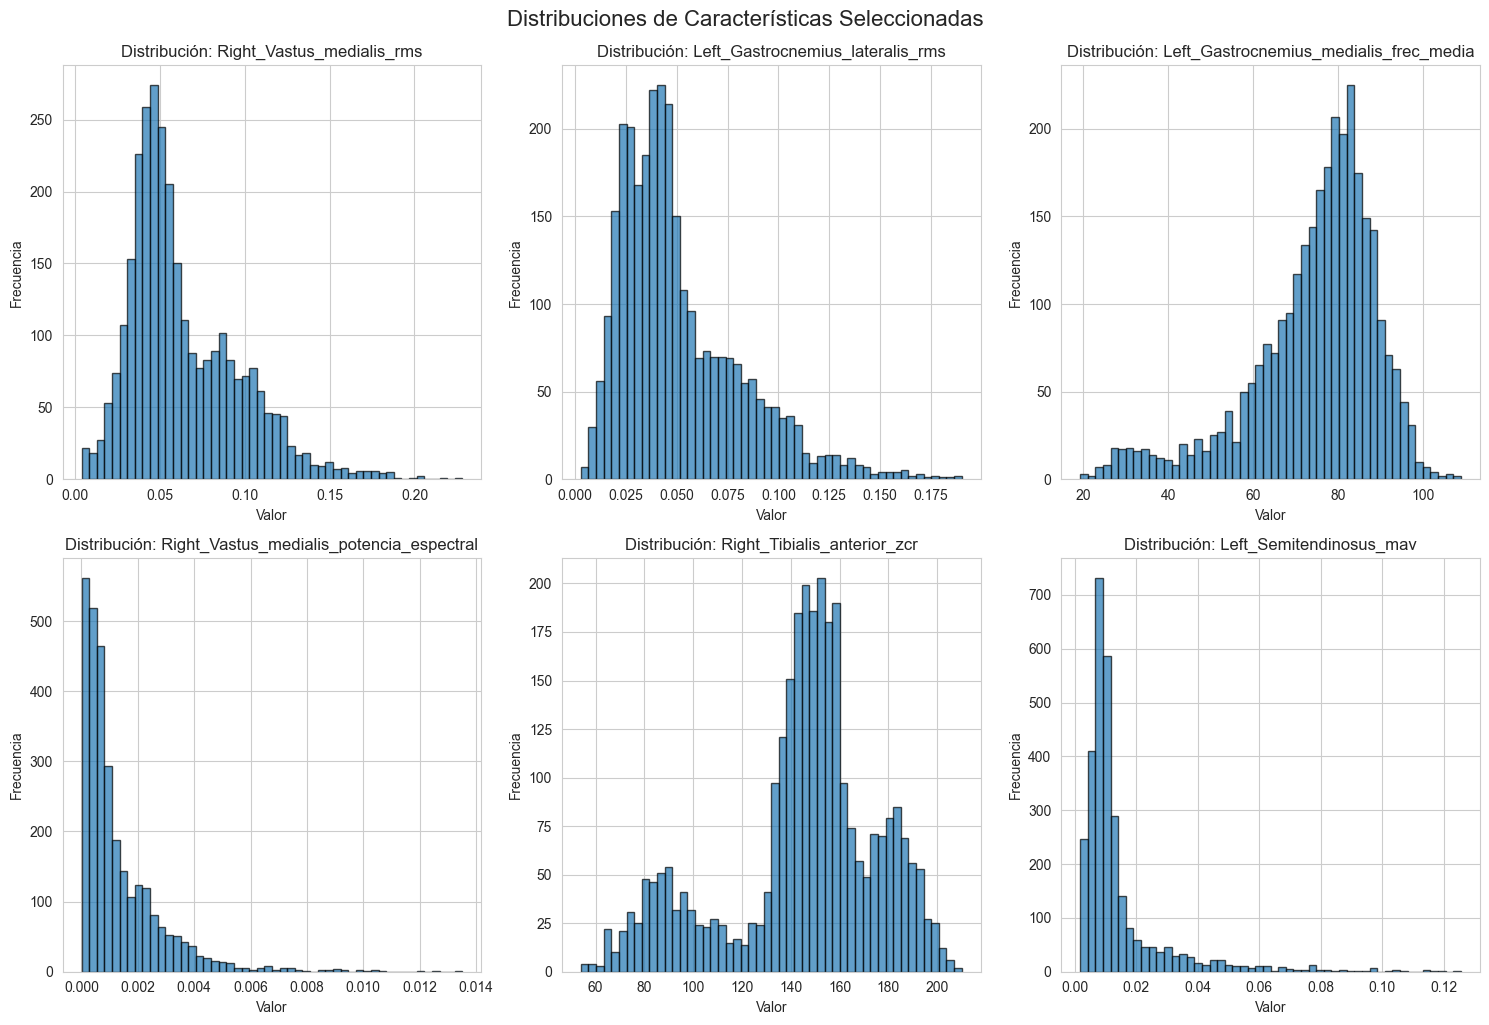

In [264]:
print("=== ESTADÍSTICOS DESCRIPTIVOS ===")
print(df.describe().round(4))
print("\n=== INFORMACIÓN DEL DATASET ===")
print(df.info())
print("\n=== VALORES NULOS ===")
nulos = df.isnull().sum()
print(nulos[nulos > 0] if any(nulos > 0) else "No hay valores nulos en el dataset.")

caracteristicas_ejemplo = [
    'Right_Vastus_medialis_rms',
    'Left_Gastrocnemius_lateralis_rms',
    'Left_Gastrocnemius_medialis_frec_media',
    'Right_Vastus_medialis_potencia_espectral',
    'Right_Tibialis_anterior_zcr',
    'Left_Semitendinosus_mav',
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(caracteristicas_ejemplo):
    if col in df.columns:
        axes[i].hist(df[col], bins=50, edgecolor='black', alpha=0.7)
        axes[i].set_title(f'Distribución: {col}')
        axes[i].set_xlabel('Valor')
        axes[i].set_ylabel('Frecuencia')
plt.tight_layout()
plt.suptitle('Distribuciones de Características Seleccionadas', y=1.02, fontsize=16)
plt.show()


**Interpretación de distribuciones:**

Los histogramas muestran que prácticamente todas las características presentan distribuciones asimétricas con cola derecha, típicas de señales de amplitud (RMS, potencia) donde los valores extremos corresponden a contracciones musculares intensas. `Right_Tibialis_anterior_zcr` es la excepción más notoria: su distribución es más compacta y centrada, lo que sugiere que la tasa de cruces por cero del tibial anterior varía menos entre ventanas. Los rangos entre características difieren varios órdenes de magnitud (RMS ~0-0.25 vs ZCR ~40-200), lo que confirma la necesidad de estandarización antes del entrenamiento.


#### **3.3 Análisis de Balance de Clases**

=== BALANCE DE CLASES ===
fatiga
0    2128
1     874
Name: count, dtype: int64

Porcentajes:
fatiga
0    70.886076
1    29.113924
Name: proportion, dtype: float64


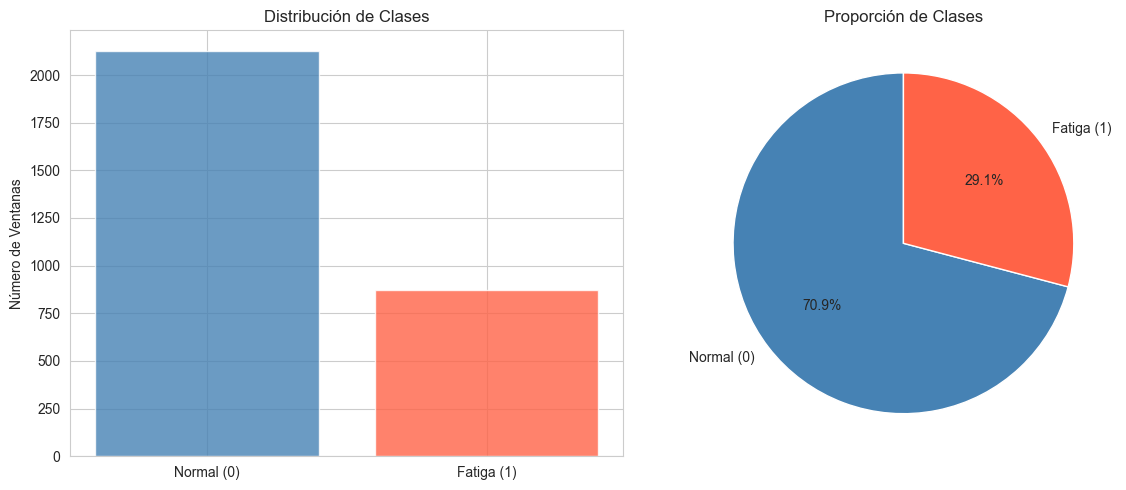

In [265]:
print("=== BALANCE DE CLASES ===")
print(df['fatiga'].value_counts())
print(f"\nPorcentajes:")
print(df['fatiga'].value_counts(normalize=True) * 100)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(['Normal (0)', 'Fatiga (1)'],
            df['fatiga'].value_counts().values,
            color=['steelblue', 'tomato'], alpha=0.8)
axes[0].set_title('Distribución de Clases')
axes[0].set_ylabel('Número de Ventanas')

axes[1].pie(df['fatiga'].value_counts().values,
            labels=['Normal (0)', 'Fatiga (1)'],
            autopct='%1.1f%%', colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Proporción de Clases')
plt.tight_layout()
plt.show()


**Interpretación del balance de clases:**

El dataset presenta un desbalance moderado: aproximadamente 71% Normal vs 29% Fatiga. Esto es esperable fisiológicamente — en una prueba de ciclismo, el tiempo en estado de fatiga muscular severa es menor que el tiempo en condición normal. Sin embargo, desde el punto de vista del modelado, este desbalance hace que un clasificador ingenuo pueda alcanzar ~71% de accuracy simplemente prediciendo siempre "Normal", razón por la cual se priorizará F1-Score y Recall sobre Accuracy como métricas de evaluación, y se aplicará SMOTE en la sección 4.4 para compensar el desbalance durante el entrenamiento.


#### **3.4 Correlaciones entre Características**

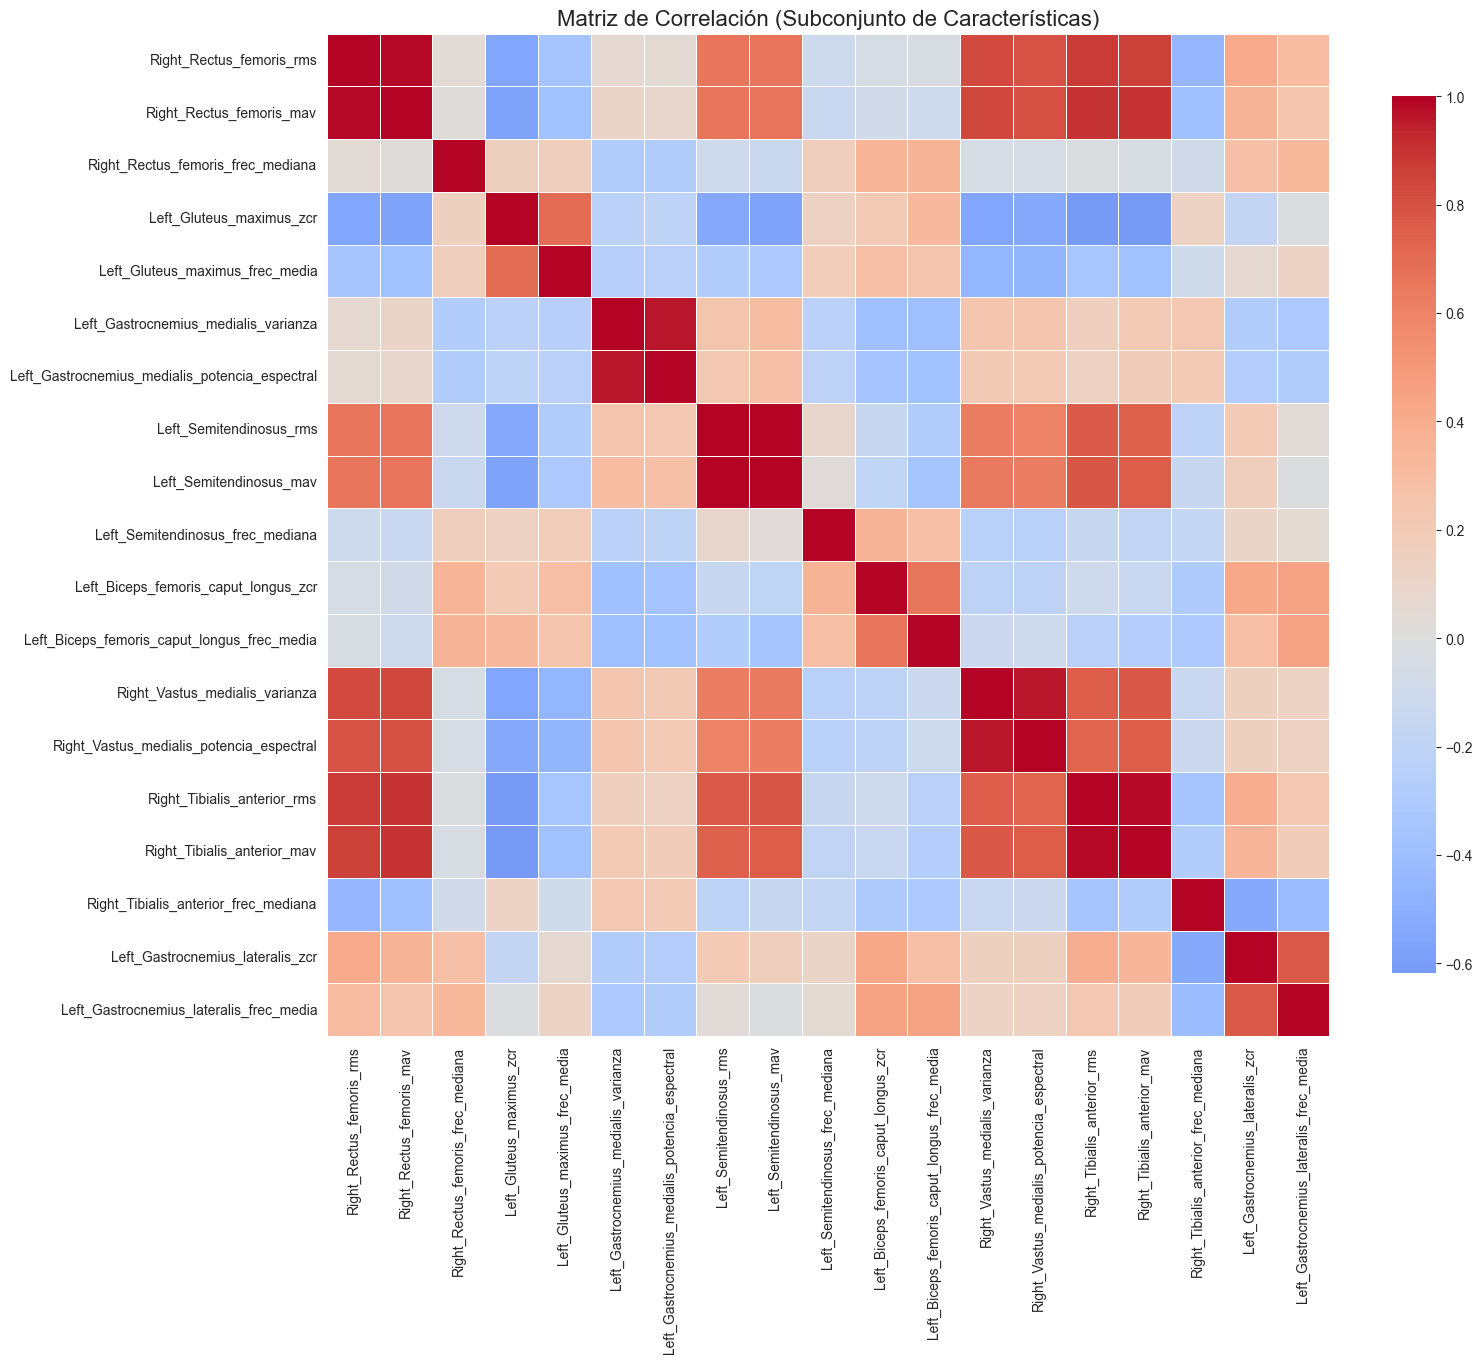

Total de pares con correlación > 0.85: 92

Primeros 10 pares más correlacionados:
  Left_Gluteus_maximus_rms <=> Left_Gluteus_maximus_mav: 0.992
  Left_Semitendinosus_rms <=> Left_Semitendinosus_mav: 0.990
  Left_Gluteus_maximus_varianza <=> Left_Gluteus_maximus_potencia_espectral: 0.988
  Right_Rectus_femoris_rms <=> Right_Rectus_femoris_mav: 0.987
  Left_Gastrocnemius_lateralis_rms <=> Left_Gastrocnemius_lateralis_mav: 0.986
  Right_Tibialis_anterior_rms <=> Right_Tibialis_anterior_mav: 0.985
  Left_Semitendinosus_varianza <=> Left_Semitendinosus_potencia_espectral: 0.985
  Left_Biceps_femoris_caput_longus_rms <=> Left_Biceps_femoris_caput_longus_mav: 0.984
  Left_Gastrocnemius_medialis_rms <=> Left_Gastrocnemius_medialis_mav: 0.980
  Left_Gastrocnemius_lateralis_varianza <=> Left_Gastrocnemius_lateralis_potencia_espectral: 0.979


In [266]:
caracteristicas = df.drop('fatiga', axis=1)
correlacion = caracteristicas.corr()

plt.figure(figsize=(16, 14))
columnas_subset = caracteristicas.columns[::3]
correlacion_subset = df[columnas_subset].corr()
sns.heatmap(correlacion_subset, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación (Subconjunto de Características)', fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

corr_alta = []
for i in range(len(correlacion.columns)):
    for j in range(i+1, len(correlacion.columns)):
        if abs(correlacion.iloc[i, j]) > 0.85:
            corr_alta.append((correlacion.columns[i], correlacion.columns[j], correlacion.iloc[i, j]))

print(f"Total de pares con correlación > 0.85: {len(corr_alta)}")
print("\nPrimeros 10 pares más correlacionados:")
corr_alta_sorted = sorted(corr_alta, key=lambda x: abs(x[2]), reverse=True)
for par in corr_alta_sorted[:10]:
    print(f"  {par[0]} <=> {par[1]}: {par[2]:.3f}")


**Interpretación de correlaciones:**

Se encontraron 92 pares de características con correlación superior a 0.85. Estos se agrupan en tres patrones:

- **RMS ↔ MAV ↔ Varianza** (mismo músculo): las tres miden amplitud o energía de la señal con diferente formulación matemática. La correlación entre ellas supera 0.98 en la mayoría de los músculos.
- **Frecuencia media ↔ Frecuencia mediana** (mismo músculo): ambas miden el centroide espectral — cuando el espectro se desplaza por fatiga, las dos se mueven juntas.
- **Misma característica entre músculos sinergistas**: durante el pedaleo, músculos como el gastrocnemio medial y lateral se activan sincrónicamente, generando correlaciones inter-músculo que reflejan la coordinación motora, no redundancia de información.

Para los modelos basados en árboles (Random Forest, XGBoost, Gradient Boosting) esta redundancia no representa un problema — el algoritmo simplemente selecciona la característica más informativa de cada grupo. Para la DNN, la regularización L2 (parámetro `alpha`) mitiga el efecto de multicolinealidad. Se mantienen todas las características para permitir que cada modelo seleccione las más útiles según su criterio propio.


#### **3.5 Relación Características vs Target (Boxplots por Clase)**

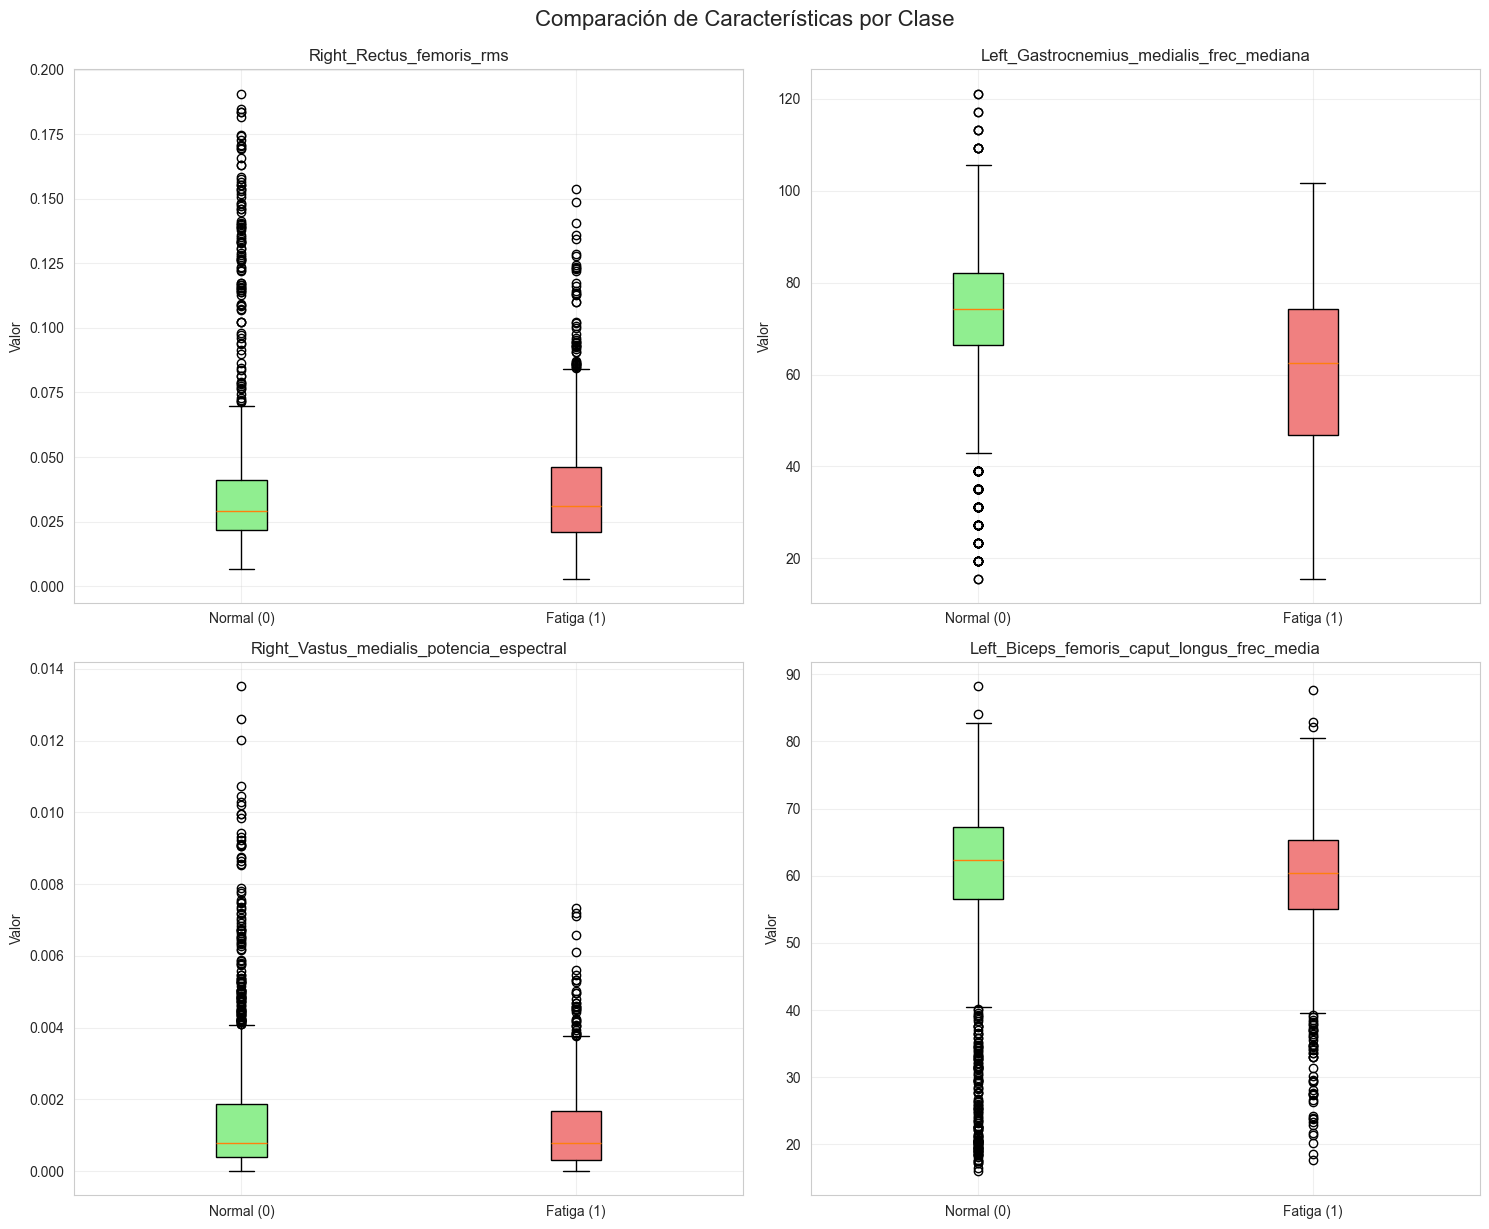

=== DIFERENCIAS RELATIVAS ENTRE CLASES ===
Right_Rectus_femoris_rms: Normal=0.0351 | Fatiga=0.0371 | Δ=5.6%
Left_Gastrocnemius_medialis_frec_mediana: Normal=73.1210 | Fatiga=58.1200 | Δ=20.5%
Right_Vastus_medialis_potencia_espectral: Normal=0.0014 | Fatiga=0.0012 | Δ=12.7%
Left_Biceps_femoris_caput_longus_frec_media: Normal=60.2295 | Fatiga=59.3566 | Δ=1.4%


In [267]:
caracteristicas_representativas = [
    'Right_Rectus_femoris_rms',
    'Left_Gastrocnemius_medialis_frec_mediana',
    'Right_Vastus_medialis_potencia_espectral',
    'Left_Biceps_femoris_caput_longus_frec_media'
]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

separabilidad = {}
for i, col in enumerate(caracteristicas_representativas):
    if col in df.columns:
        data_plot = [df[df['fatiga'] == 0][col].dropna(),
                     df[df['fatiga'] == 1][col].dropna()]
        bp = axes[i].boxplot(data_plot, tick_labels=['Normal (0)', 'Fatiga (1)'], patch_artist=True)
        bp['boxes'][0].set_facecolor('lightgreen')
        bp['boxes'][1].set_facecolor('lightcoral')
        axes[i].set_title(f'{col}')
        axes[i].set_ylabel('Valor')
        axes[i].grid(True, alpha=0.3)

        media_0 = df[df['fatiga'] == 0][col].mean()
        media_1 = df[df['fatiga'] == 1][col].mean()
        diff_pct = abs((media_1 - media_0) / media_0) * 100 if media_0 != 0 else 0
        separabilidad[col] = {'media_normal': media_0, 'media_fatiga': media_1, 'diff_pct': diff_pct}

plt.tight_layout()
plt.suptitle('Comparación de Características por Clase', y=1.02, fontsize=16)
plt.show()

print("=== DIFERENCIAS RELATIVAS ENTRE CLASES ===")
for col, vals in separabilidad.items():
    print(f"{col}: Normal={vals['media_normal']:.4f} | Fatiga={vals['media_fatiga']:.4f} | Δ={vals['diff_pct']:.1f}%")


**Interpretación de separabilidad:**

De las cuatro características visualizadas, `Left_Gastrocnemius_medialis_frec_mediana` es la más discriminante (diferencia relativa ~20%): los boxplots muestran poca superposición entre clases, con la distribución de fatiga desplazada claramente hacia frecuencias menores. Esto es consistente con el mecanismo fisiológico clásico: la fatiga desacelera la conducción en las fibras musculares tipo II, corriendo el espectro EMG hacia frecuencias bajas.

`Right_Rectus_femoris_rms` y `Right_Vastus_medialis_potencia_espectral` presentan alta superposición entre clases y comportamiento contrario al esperado teóricamente: su amplitud/potencia es menor en fatiga. Esto se explica por compensación muscular: cuando el recto femoral y el vasto medial se fatigan, el cuerpo redistribuye la carga hacia otros músculos (bíceps femoral, gastrocnemio), por lo que la actividad EMG de estos músculos puede reducirse en las fases avanzadas de fatiga.

Esta heterogeneidad confirma que ninguna característica individual es suficiente para clasificar; el modelo debe combinar múltiples señales para lograr buena separación.


### **4. Procesamiento de Datos**

#### **4.1 Separación de Features y Target**

In [268]:
# Separar características (X) y variable objetivo (y)
X = df.drop('fatiga', axis=1)
y = df['fatiga']

print(f"Dimensiones de X (características): {X.shape}")
print(f"Dimensiones de y (target): {y.shape}")
print(f"\nDistribución del target en el dataset completo:")
print(y.value_counts(normalize=True) * 100)

Dimensiones de X (características): (3002, 56)
Dimensiones de y (target): (3002,)

Distribución del target en el dataset completo:
fatiga
0    70.886076
1    29.113924
Name: proportion, dtype: float64


#### **4.2 División en Train, Validation y Test (70/15/15)**

Justificacion de las proporciones:

- **Train (70%):**
    - Es el estándar en machine learning cuando se tienen datasets de tamaño moderado (∼3000 muestras).
    - Proporciona suficientes ejemplos (∼2100) para que los modelos aprendan patrones complejos sin sobreajustar.
    - Para tree-based models y DNN, más datos de entrenamiento generalmente mejora la generalización.

- **Validation (15%)**:
    - Suficiente (∼450 muestras) para evaluar hiperparámetros de forma confiable.
    - Conjunto de validación más pequeño que 20% permite mantener más datos para entrenamiento.
    - La estratificación asegura que la proporción de clases se mantenga incluso con este tamaño.

- **Test (15%)**:
    - Similar a validación, ∼450 muestras son suficientes para una evaluación final robusta.
    - Proporción igual a validación facilita comparación directa de métricas.
    - Mantener test separado y no usarlo hasta el final previene data leakage.

In [269]:
# Primera división: separar 70% para entrenamiento y 30% para temporal (validación + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Segunda división: dividir el 30% temporal en 15% validación y 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("=== DIVISIÓN DE DATOS ===")
print(f"Entrenamiento (70%): {X_train.shape[0]} muestras")
print(f"  Distribución: {np.bincount(y_train) / len(y_train) * 100}")
print(f"Validación (15%): {X_val.shape[0]} muestras")
print(f"  Distribución: {np.bincount(y_val) / len(y_val) * 100}")
print(f"Test (15%): {X_test.shape[0]} muestras")
print(f"  Distribución: {np.bincount(y_test) / len(y_test) * 100}")

# Verificar que la estratificación funcionó
print("\nVerificación de estratificación (proporciones similares):")
print(f"Train - % Fatiga: {y_train.mean()*100:.2f}%")
print(f"Val   - % Fatiga: {y_val.mean()*100:.2f}%")
print(f"Test  - % Fatiga: {y_test.mean()*100:.2f}%")

=== DIVISIÓN DE DATOS ===
Entrenamiento (70%): 2101 muestras
  Distribución: [70.8710138 29.1289862]
Validación (15%): 450 muestras
  Distribución: [70.88888889 29.11111111]
Test (15%): 451 muestras
  Distribución: [70.95343681 29.04656319]

Verificación de estratificación (proporciones similares):
Train - % Fatiga: 29.13%
Val   - % Fatiga: 29.11%
Test  - % Fatiga: 29.05%


#### **4.3 Pipeline de Procesamiento con Scikit-learn**

In [270]:
# Crear pipeline de preprocesamiento
# Como todas las variables son numéricas, solo necesitamos estandarización
preprocessing_pipeline = Pipeline([
    ('scaler', StandardScaler())  # Estandarización (media=0, desviación=1)
])

# Ajustar el pipeline con datos de entrenamiento y transformar
X_train_scaled = preprocessing_pipeline.fit_transform(X_train)
X_val_scaled = preprocessing_pipeline.transform(X_val)
X_test_scaled = preprocessing_pipeline.transform(X_test)

# Convertir a DataFrame para mantener nombres de columnas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_train.columns)

print("=== PIPELINE DE PROCESAMIENTO ===")
print("Pipeline creado con StandardScaler")
print(f"Media de características después de estandarización (train):")
print(f"  Media: {X_train_scaled.mean().mean():.2f} (debe ser ~0)")
print(f"  Desviación: {X_train_scaled.std().mean():.2f} (debe ser ~1)")

# Verificar que no hay valores nulos
print(f"\nValores nulos en train: {X_train_scaled.isnull().sum().sum()}")
print(f"Valores nulos en val: {X_val_scaled.isnull().sum().sum()}")
print(f"Valores nulos en test: {X_test_scaled.isnull().sum().sum()}")

=== PIPELINE DE PROCESAMIENTO ===
Pipeline creado con StandardScaler
Media de características después de estandarización (train):
  Media: -0.00 (debe ser ~0)
  Desviación: 1.00 (debe ser ~1)

Valores nulos en train: 0
Valores nulos en val: 0
Valores nulos en test: 0


=== ANÁLISIS DE DESBALANCE DE CLASES ===
  Normal (0): 1489 muestras (70.9%)
  Fatiga  (1): 612 muestras (29.1%)
  Ratio desbalance: 2.43:1

=== DISTRIBUCIÓN DESPUÉS DE SMOTE ===
  Normal (0): 1489 muestras (55.6%)
  Fatiga  (1): 1191 muestras (44.4%)
  Total: 2680


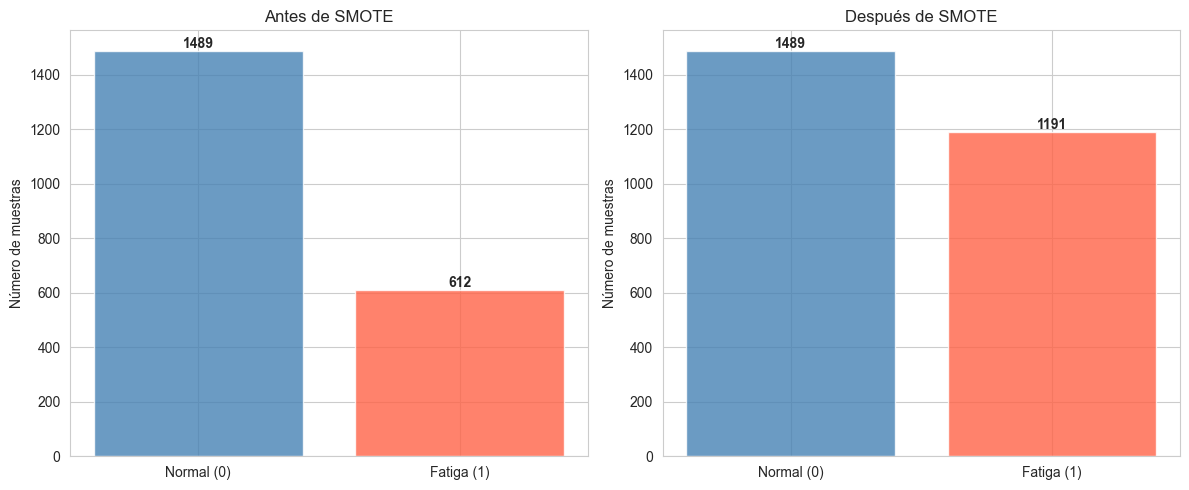

In [271]:
from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_class_weight

print("=== ANÁLISIS DE DESBALANCE DE CLASES ===")
print(f"  Normal (0): {sum(y_train == 0)} muestras ({sum(y_train == 0)/len(y_train)*100:.1f}%)")
print(f"  Fatiga  (1): {sum(y_train == 1)} muestras ({sum(y_train == 1)/len(y_train)*100:.1f}%)")
print(f"  Ratio desbalance: {(1 - y_train.mean()) / y_train.mean():.2f}:1")

smote = SMOTE(random_state=42, k_neighbors=5, sampling_strategy=0.8)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

X_train_smote = pd.DataFrame(X_train_smote, columns=X_train.columns)
y_train_smote = pd.Series(y_train_smote)

print("\n=== DISTRIBUCIÓN DESPUÉS DE SMOTE ===")
print(f"  Normal (0): {sum(y_train_smote == 0)} muestras ({sum(y_train_smote == 0)/len(y_train_smote)*100:.1f}%)")
print(f"  Fatiga  (1): {sum(y_train_smote == 1)} muestras ({sum(y_train_smote == 1)/len(y_train_smote)*100:.1f}%)")
print(f"  Total: {len(y_train_smote)}")

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
pesos_dict = {0: class_weights[0], 1: class_weights[1]}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, datos, titulo in zip(axes,
    [[sum(y_train == 0), sum(y_train == 1)],
     [sum(y_train_smote == 0), sum(y_train_smote == 1)]],
    ['Antes de SMOTE', 'Después de SMOTE']):
    bars = ax.bar(['Normal (0)', 'Fatiga (1)'], datos, color=['steelblue', 'tomato'], alpha=0.8)
    ax.set_title(titulo)
    ax.set_ylabel('Número de muestras')
    for bar, v in zip(bars, datos):
        ax.text(bar.get_x() + bar.get_width()/2, v + 10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


#### **Justificación: SMOTE como estrategia de balanceo**

**¿Por qué SMOTE y no solo class_weight?**

Los pesos de clase le dicen al modelo que se equivocarse en la clase minoritaria es más costoso, pero **no cambia la distribución de datos que el modelo ve**. En nuestro caso, con un desbalance ~70/30, el modelo tenía tendencia a ignorar la frontera de decisión de la clase minoritaria.

SMOTE (Synthetic Minority Over-sampling Technique) **genera ejemplos sintéticos plausibles** de la clase minoritaria interpolando entre vecinos reales, lo que efectivamente balancea las clases y obliga al modelo a aprender mejor la frontera de la clase de fatiga.

| Técnica | Aplica sobre | Efecto principal |
|---|---|---|
| **Solo class_weight** | Función de pérdida | Penaliza más errores en clase minoritaria |
| **Solo SMOTE** | Datos de entrenamiento | Balancea la distribución vista por el modelo |
| **SMOTE + class_weight** | Ambos | Efecto combinado: balance + penalización |

**Importante:** SMOTE se aplica **únicamente** sobre `X_train_scaled`. Los conjuntos `X_val` y `X_test` conservan la distribución original, de modo que la evaluación refleja el rendimiento en datos reales desbalanceados.

**Nota fisiológica:** A diferencia de aplicar SMOTE directamente sobre la señal EMG cruda (donde sería más riesgoso), aquí se aplica sobre el **espacio de características** (RMS, frecuencias, etc.), donde la interpolación tiene mayor sentido ya que las características son continuas y los vecinos tienen patrones similares.

### **5. Entrenamiento y Comparación de Modelos**

#### **5.1** Praparación para el entrenamiento

Antes de entrenar los modelos, verificamos que los datos estén correctamente escalados y preparados.

In [272]:
print("=== CONJUNTOS DE DATOS PREPARADOS ===")
print(f"X_train_scaled (original): {X_train_scaled.shape}")
print(f"X_train_smote (balanceado): {X_train_smote.shape}")
print(f"X_val_scaled:  {X_val_scaled.shape}")
print(f"X_test_scaled: {X_test_scaled.shape}")
print("\n=== DISTRIBUCIÓN DE CLASES ===")
print("Train SMOTE:", np.bincount(y_train_smote) / len(y_train_smote) * 100)
print("Val (original):", np.bincount(y_val) / len(y_val) * 100)
print("Test (original):", np.bincount(y_test) / len(y_test) * 100)


=== CONJUNTOS DE DATOS PREPARADOS ===
X_train_scaled (original): (2101, 56)
X_train_smote (balanceado): (2680, 56)
X_val_scaled:  (450, 56)
X_test_scaled: (451, 56)

=== DISTRIBUCIÓN DE CLASES ===
Train SMOTE: [55.55970149 44.44029851]
Val (original): [70.88888889 29.11111111]
Test (original): [70.95343681 29.04656319]


#### **5.2 Función para Evaluar Modelos**

In [273]:
def evaluar_modelo(modelo, X_train, y_train, X_val, y_val, X_test, y_test, nombre_modelo):
    """
    Evalúa un modelo en train, val y test, y retorna un diccionario con métricas.
    """
    # Predicciones
    y_train_pred = modelo.predict(X_train)
    y_val_pred = modelo.predict(X_val)
    y_test_pred = modelo.predict(X_test)
    
    # Calcular métricas
    metrics = {
        'Modelo': nombre_modelo,
        'Train_Accuracy': accuracy_score(y_train, y_train_pred),
        'Train_Precision': precision_score(y_train, y_train_pred, zero_division=0),
        'Train_Recall': recall_score(y_train, y_train_pred, zero_division=0),
        'Train_F1': f1_score(y_train, y_train_pred, zero_division=0),
        'Val_Accuracy': accuracy_score(y_val, y_val_pred),
        'Val_Precision': precision_score(y_val, y_val_pred, zero_division=0),
        'Val_Recall': recall_score(y_val, y_val_pred, zero_division=0),
        'Val_F1': f1_score(y_val, y_val_pred, zero_division=0),
        'Test_Accuracy': accuracy_score(y_test, y_test_pred),
        'Test_Precision': precision_score(y_test, y_test_pred, zero_division=0),
        'Test_Recall': recall_score(y_test, y_test_pred, zero_division=0),
        'Test_F1': f1_score(y_test, y_test_pred, zero_division=0)
    }
    
    return metrics

#### **5.3 Modelo 1: k-Nearest Neighbors (kNN)**

In [274]:
from sklearn.neighbors import KNeighborsClassifier

print("=== ENTRENANDO KNN ===")

param_grid_knn = {
    'n_neighbors': [9, 11, 15, 21, 31, 41],
    'weights': ['uniform'],
    'metric': ['euclidean', 'manhattan']
}

knn = KNeighborsClassifier()
grid_search_knn = GridSearchCV(knn, param_grid_knn, cv=5, scoring='f1', n_jobs=-1, verbose=0)
grid_search_knn.fit(X_train_smote, y_train_smote)

best_knn = grid_search_knn.best_estimator_
print(f"Mejores hiperparámetros: {grid_search_knn.best_params_}")
print(f"Mejor F1 (CV): {grid_search_knn.best_score_:.4f}")

knn_metrics = evaluar_modelo(best_knn, X_train_smote, y_train_smote,
                              X_val_scaled, y_val, X_test_scaled, y_test, 'kNN')
print(f"Train F1={knn_metrics['Train_F1']:.4f} | Val F1={knn_metrics['Val_F1']:.4f} | "
      f"Test F1={knn_metrics['Test_F1']:.4f} | Gap={knn_metrics['Train_F1']-knn_metrics['Val_F1']:.4f}")


=== ENTRENANDO KNN ===
Mejores hiperparámetros: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'uniform'}
Mejor F1 (CV): 0.8564
Train F1=0.8918 | Val F1=0.7467 | Test F1=0.8000 | Gap=0.1451


#### **5.4 Modelo 2: Decision Tree**

In [275]:
from sklearn.tree import DecisionTreeClassifier

print("=== ENTRENANDO DECISION TREE ===")

param_grid_dt = {
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [30, 50, 80, 100],
    'min_samples_leaf': [15, 25, 40, 60],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced']
}

dt = DecisionTreeClassifier(random_state=42)
random_search_dt = RandomizedSearchCV(dt, param_grid_dt, n_iter=40, cv=5,
                                       scoring='f1', random_state=42, n_jobs=-1, verbose=0)
random_search_dt.fit(X_train_smote, y_train_smote)

best_dt = random_search_dt.best_estimator_
print(f"Mejores hiperparámetros: {random_search_dt.best_params_}")
print(f"Mejor F1 (CV): {random_search_dt.best_score_:.4f} | Profundidad: {best_dt.get_depth()}")

dt_metrics = evaluar_modelo(best_dt, X_train_smote, y_train_smote,
                             X_val_scaled, y_val, X_test_scaled, y_test, 'Decision Tree')
print(f"Train F1={dt_metrics['Train_F1']:.4f} | Val F1={dt_metrics['Val_F1']:.4f} | "
      f"Test F1={dt_metrics['Test_F1']:.4f} | Gap={dt_metrics['Train_F1']-dt_metrics['Val_F1']:.4f}")


=== ENTRENANDO DECISION TREE ===
Mejores hiperparámetros: {'min_samples_split': 30, 'min_samples_leaf': 40, 'max_depth': 6, 'criterion': 'gini', 'class_weight': 'balanced'}
Mejor F1 (CV): 0.7794 | Profundidad: 6
Train F1=0.8198 | Val F1=0.6450 | Test F1=0.6839 | Gap=0.1748


#### **5.5 Modelo 3: Random Forest**

In [276]:
from sklearn.ensemble import RandomForestClassifier

print("=== ENTRENANDO RANDOM FOREST (con SMOTE + regularización) ===")

# Regularización explícita para reducir gap train-val
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [8, 12, 16, 20],          # Evitar None (árboles profundos completos)
    'min_samples_split': [10, 20, 30],     # Split mínimo moderado
    'min_samples_leaf': [5, 10, 15],       # Hojas con más muestras
    'max_features': ['sqrt', 'log2'],
    'max_samples': [0.7, 0.8, 0.9],        # Subsampling de filas (bagging fraction)
    'class_weight': ['balanced'],
    'min_impurity_decrease': [0.0, 0.001, 0.005, 0.01]
}

rf = RandomForestClassifier(random_state=42, oob_score=True)
random_search_rf = RandomizedSearchCV(
    rf,
    param_grid_rf,
    n_iter=50,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Entrenar con datos SMOTE
random_search_rf.fit(X_train_smote, y_train_smote)

best_rf = random_search_rf.best_estimator_
print(f"\nMejores hiperparámetros: {random_search_rf.best_params_}")
print(f"Mejor puntuación F1 (CV): {random_search_rf.best_score_:.4f}")
print(f"OOB Score: {best_rf.oob_score_:.4f}")

# Evaluar
rf_metrics = evaluar_modelo(
    best_rf,
    X_train_smote, y_train_smote,
    X_val_scaled, y_val,
    X_test_scaled, y_test,
    'Random Forest'
)

print(f"\nTrain  - Accuracy: {rf_metrics['Train_Accuracy']:.4f}, F1: {rf_metrics['Train_F1']:.4f}")
print(f"Val    - Accuracy: {rf_metrics['Val_Accuracy']:.4f}, F1: {rf_metrics['Val_F1']:.4f}")
print(f"Test   - Accuracy: {rf_metrics['Test_Accuracy']:.4f}, F1: {rf_metrics['Test_F1']:.4f}")
print(f"\nGap Train-Val (F1): {rf_metrics['Train_F1'] - rf_metrics['Val_F1']:.4f}")


=== ENTRENANDO RANDOM FOREST (con SMOTE + regularización) ===
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Mejores hiperparámetros: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 5, 'min_impurity_decrease': 0.0, 'max_samples': 0.8, 'max_features': 'sqrt', 'max_depth': 12, 'class_weight': 'balanced'}
Mejor puntuación F1 (CV): 0.8677
OOB Score: 0.8832

Train  - Accuracy: 0.9593, F1: 0.9543
Val    - Accuracy: 0.8733, F1: 0.7897
Test   - Accuracy: 0.8891, F1: 0.8120

Gap Train-Val (F1): 0.1646


#### **5.6 Modelo 4: Gradient Boosting**

In [277]:
from sklearn.ensemble import GradientBoostingClassifier

print("=== ENTRENANDO GRADIENT BOOSTING ===")

param_grid_gb = {
    'n_estimators': [100, 150, 200],
    'max_depth': [2, 3],
    'learning_rate': [0.01, 0.05, 0.08],
    'min_samples_split': [40, 60, 80],
    'min_samples_leaf': [20, 30, 40],
    'subsample': [0.5, 0.6, 0.7],
    'max_features': ['sqrt', 0.4]
}

gb = GradientBoostingClassifier(random_state=42, validation_fraction=0.15,
                                 n_iter_no_change=15, tol=1e-4)
random_search_gb = RandomizedSearchCV(gb, param_grid_gb, n_iter=50, cv=5,
                                       scoring='f1', random_state=42, n_jobs=-1, verbose=0)
random_search_gb.fit(X_train_smote, y_train_smote)

best_gb = random_search_gb.best_estimator_
print(f"Mejores hiperparámetros: {random_search_gb.best_params_}")
print(f"Mejor F1 (CV): {random_search_gb.best_score_:.4f} | Estimadores usados: {best_gb.n_estimators_}")

gb_metrics = evaluar_modelo(best_gb, X_train_smote, y_train_smote,
                             X_val_scaled, y_val, X_test_scaled, y_test, 'Gradient Boosting')
print(f"Train F1={gb_metrics['Train_F1']:.4f} | Val F1={gb_metrics['Val_F1']:.4f} | "
      f"Test F1={gb_metrics['Test_F1']:.4f} | Gap={gb_metrics['Train_F1']-gb_metrics['Val_F1']:.4f}")


=== ENTRENANDO GRADIENT BOOSTING ===
Mejores hiperparámetros: {'subsample': 0.6, 'n_estimators': 200, 'min_samples_split': 80, 'min_samples_leaf': 40, 'max_features': 'sqrt', 'max_depth': 3, 'learning_rate': 0.08}
Mejor F1 (CV): 0.8395 | Estimadores usados: 200
Train F1=0.9115 | Val F1=0.7361 | Test F1=0.7761 | Gap=0.1754


#### **5.7 Modelo 5: XGBoost**

In [278]:
from xgboost import XGBClassifier

print("=== ENTRENANDO XGBOOST ===")

param_grid_xgb = {
    'n_estimators': [100, 150, 200, 300],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_child_weight': [10, 20, 30],
    'subsample': [0.5, 0.6, 0.7],
    'colsample_bytree': [0.5, 0.6, 0.8],
    'reg_alpha': [0.1, 0.5, 1.0],
    'reg_lambda': [1.0, 2.0, 5.0],
    'gamma': [0.1, 0.5, 1.0]
}

xgb = XGBClassifier(random_state=42, eval_metric='logloss',
                     early_stopping_rounds=15, verbosity=0)

random_search_xgb = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    param_grid_xgb, n_iter=50, cv=5,
    scoring='f1', random_state=42, n_jobs=-1, verbose=0
)
random_search_xgb.fit(X_train_smote, y_train_smote)

best_xgb = random_search_xgb.best_estimator_
print(f"Mejores hiperparámetros: {random_search_xgb.best_params_}")
print(f"Mejor F1 (CV): {random_search_xgb.best_score_:.4f}")

xgb_metrics = evaluar_modelo(best_xgb, X_train_smote, y_train_smote,
                              X_val_scaled, y_val, X_test_scaled, y_test, 'XGBoost')
print(f"Train F1={xgb_metrics['Train_F1']:.4f} | Val F1={xgb_metrics['Val_F1']:.4f} | "
      f"Test F1={xgb_metrics['Test_F1']:.4f} | Gap={xgb_metrics['Train_F1']-xgb_metrics['Val_F1']:.4f}")


=== ENTRENANDO XGBOOST ===
Mejores hiperparámetros: {'subsample': 0.7, 'reg_lambda': 2.0, 'reg_alpha': 0.1, 'n_estimators': 300, 'min_child_weight': 10, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0.5, 'colsample_bytree': 0.8}
Mejor F1 (CV): 0.8624
Train F1=0.9533 | Val F1=0.7786 | Test F1=0.7912 | Gap=0.1747


#### **5.8 Modelo 6: Deep Neural Network (DNN)**

=== ENTRENANDO DNN ===
Mejores hiperparámetros: {'validation_fraction': 0.15, 'n_iter_no_change': 20, 'learning_rate_init': 0.005, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (32, 16, 8), 'early_stopping': True, 'batch_size': 128, 'alpha': 0.1, 'activation': 'tanh'}
Mejor F1 (CV): 0.8765
Train F1=0.9163 | Val F1=0.7361 | Test F1=0.7357 | Gap=0.1803


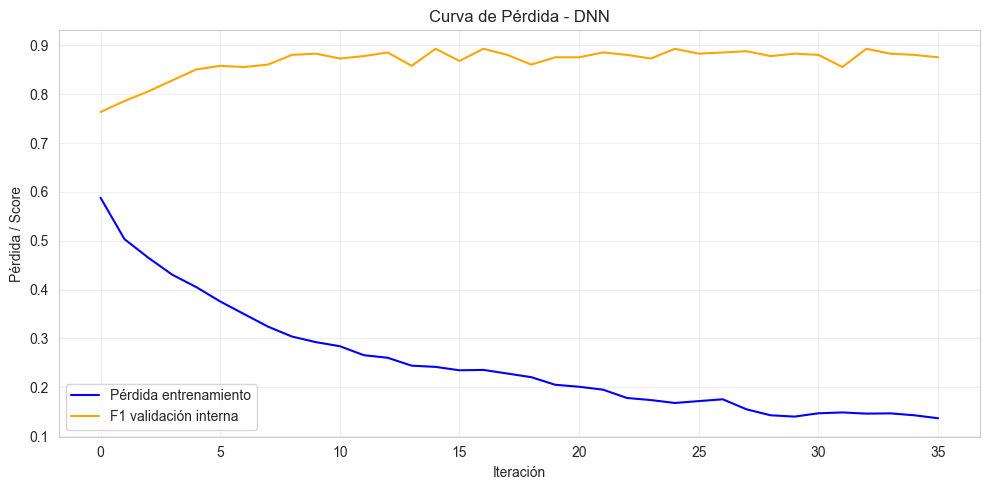

In [279]:
from sklearn.neural_network import MLPClassifier

print("=== ENTRENANDO DNN ===")

param_grid_dnn = {
    'hidden_layer_sizes': [
        (32, 16),
        (64, 32),
        (32, 16, 8),
        (64, 32, 16),
        (64, 32, 16, 8),
    ],
    'activation': ['relu', 'tanh'],
    'alpha': [0.05, 0.1, 0.2, 0.5],
    'learning_rate': ['adaptive'],
    'learning_rate_init': [0.001, 0.005],
    'batch_size': [128, 256],
    'early_stopping': [True],
    'validation_fraction': [0.15],
    'n_iter_no_change': [20]
}

dnn = MLPClassifier(random_state=42, max_iter=300, verbose=False)
random_search_dnn = RandomizedSearchCV(dnn, param_grid_dnn, n_iter=40, cv=5,
                                        scoring='f1', random_state=42, n_jobs=-1, verbose=0)
random_search_dnn.fit(X_train_smote, y_train_smote)

best_dnn = random_search_dnn.best_estimator_
print(f"Mejores hiperparámetros: {random_search_dnn.best_params_}")
print(f"Mejor F1 (CV): {random_search_dnn.best_score_:.4f}")

dnn_metrics = evaluar_modelo(best_dnn, X_train_smote, y_train_smote,
                              X_val_scaled, y_val, X_test_scaled, y_test, 'DNN')
print(f"Train F1={dnn_metrics['Train_F1']:.4f} | Val F1={dnn_metrics['Val_F1']:.4f} | "
      f"Test F1={dnn_metrics['Test_F1']:.4f} | Gap={dnn_metrics['Train_F1']-dnn_metrics['Val_F1']:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(best_dnn.loss_curve_, label='Pérdida entrenamiento', color='blue')
if hasattr(best_dnn, 'validation_scores_') and best_dnn.validation_scores_:
    plt.plot(best_dnn.validation_scores_, label='F1 validación interna', color='orange')
plt.title('Curva de Pérdida - DNN')
plt.xlabel('Iteración')
plt.ylabel('Pérdida / Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


#### **5.9 Tabla Comparativa de Modelos**

=== TABLA COMPARATIVA DE MODELOS ===
Entrenados con SMOTE | Val y Test con distribución original
           Modelo  Train_Accuracy  Train_Precision  Train_Recall  Train_F1  Val_Accuracy  Val_Precision  Val_Recall  Val_F1  Test_Accuracy  Test_Precision  Test_Recall  Test_F1
              kNN          0.9011           0.8680        0.9169    0.8918        0.8311         0.6627      0.8550  0.7467         0.8714          0.7296       0.8855   0.8000
    Decision Tree          0.8313           0.7806        0.8631    0.8198        0.7578         0.5625      0.7557  0.6450         0.7827          0.5922       0.8092   0.6839
    Random Forest          0.9593           0.9539        0.9547    0.9543        0.8733         0.7643      0.8168  0.7897         0.8891          0.8000       0.8244   0.8120
Gradient Boosting          0.9224           0.9241        0.8992    0.9115        0.8422         0.7174      0.7557  0.7361         0.8670          0.7591       0.7939   0.7761
          XGBoost 

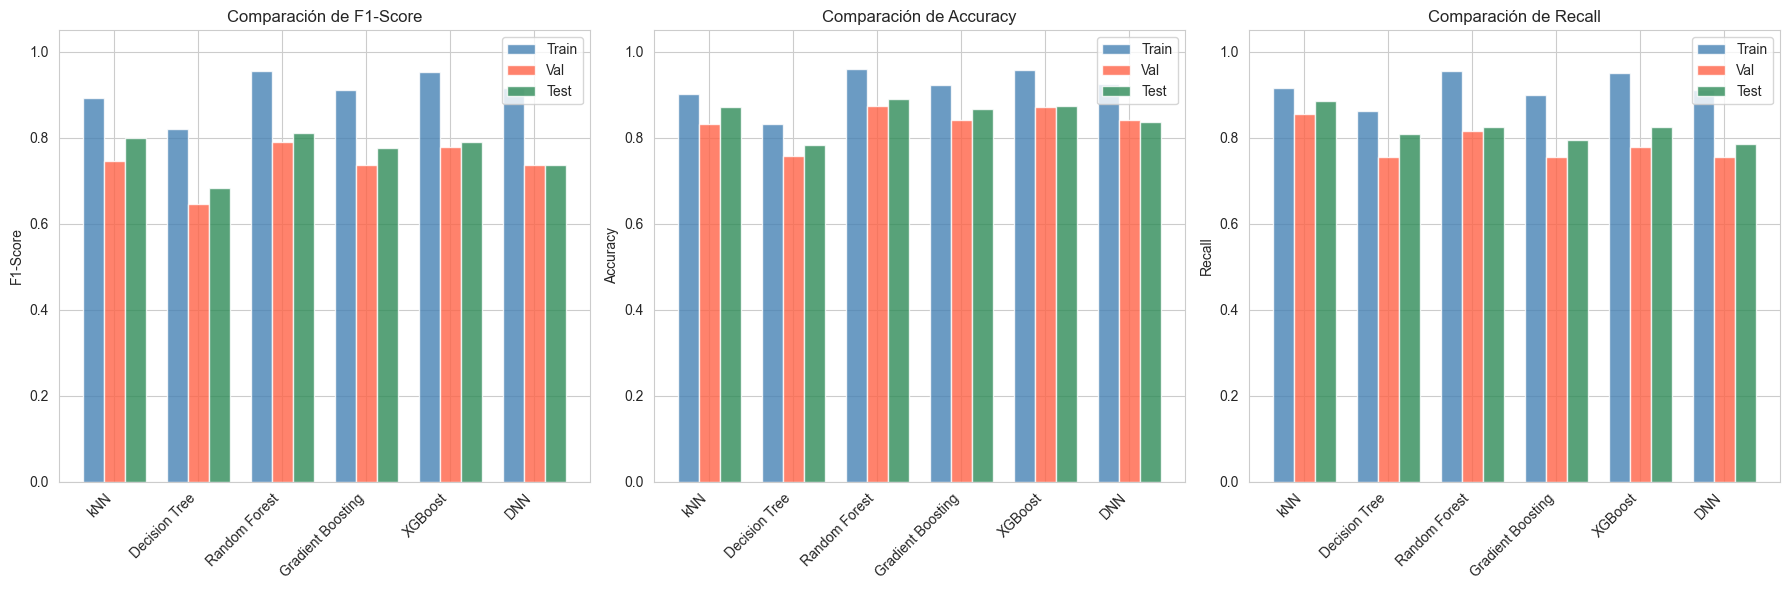

In [280]:
resultados = pd.DataFrame([
    knn_metrics, dt_metrics, rf_metrics,
    gb_metrics, xgb_metrics, dnn_metrics
])

column_order = ['Modelo',
                'Train_Accuracy', 'Train_Precision', 'Train_Recall', 'Train_F1',
                'Val_Accuracy',   'Val_Precision',   'Val_Recall',   'Val_F1',
                'Test_Accuracy',  'Test_Precision',  'Test_Recall',  'Test_F1']
resultados = resultados[column_order]

print("=== TABLA COMPARATIVA DE MODELOS ===")
print("Entrenados con SMOTE | Val y Test con distribución original")
print(resultados.round(4).to_string(index=False))

print("\n=== MEJORES POR MÉTRICA (VALIDACIÓN) ===")
for metrica in ['Val_Accuracy', 'Val_Precision', 'Val_Recall', 'Val_F1']:
    idx = resultados[metrica].idxmax()
    print(f"{metrica}: {resultados.loc[idx, 'Modelo']} ({resultados.loc[idx, metrica]:.4f})")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metricas_plot = [('Train_F1', 'Val_F1', 'Test_F1', 'F1-Score'),
                 ('Train_Accuracy', 'Val_Accuracy', 'Test_Accuracy', 'Accuracy'),
                 ('Train_Recall', 'Val_Recall', 'Test_Recall', 'Recall')]

x = np.arange(len(resultados))
width = 0.25

for ax, (tr, vl, te, title) in zip(axes, metricas_plot):
    ax.bar(x - width, resultados[tr], width, label='Train', color='steelblue', alpha=0.8)
    ax.bar(x,         resultados[vl], width, label='Val',   color='tomato',    alpha=0.8)
    ax.bar(x + width, resultados[te], width, label='Test',  color='seagreen',  alpha=0.8)
    ax.set_title(f'Comparación de {title}')
    ax.set_ylabel(title)
    ax.set_xticks(x)
    ax.set_xticklabels(resultados['Modelo'], rotation=45, ha='right')
    ax.legend()
    ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()


#### **5.10 Curvas de Entrenamiento y Validación**

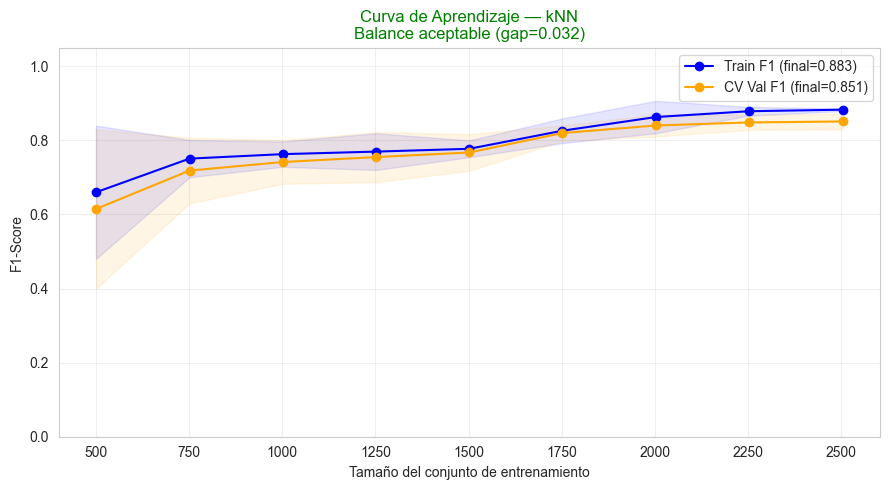

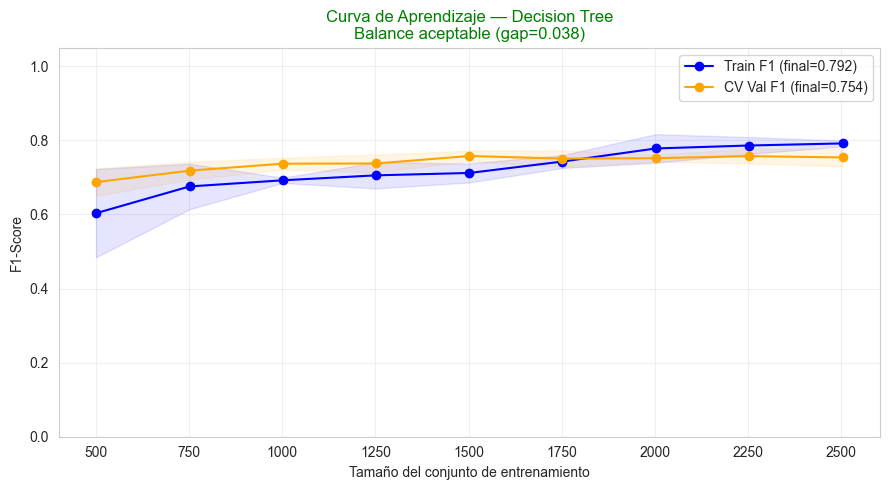

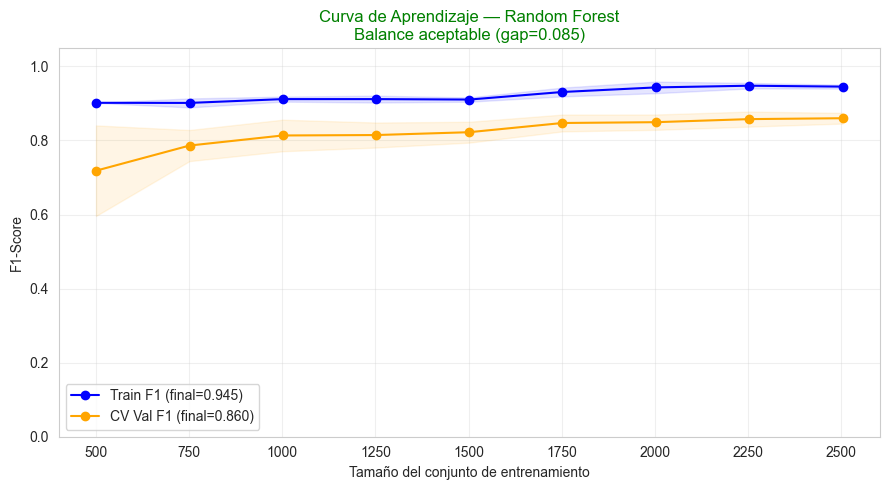

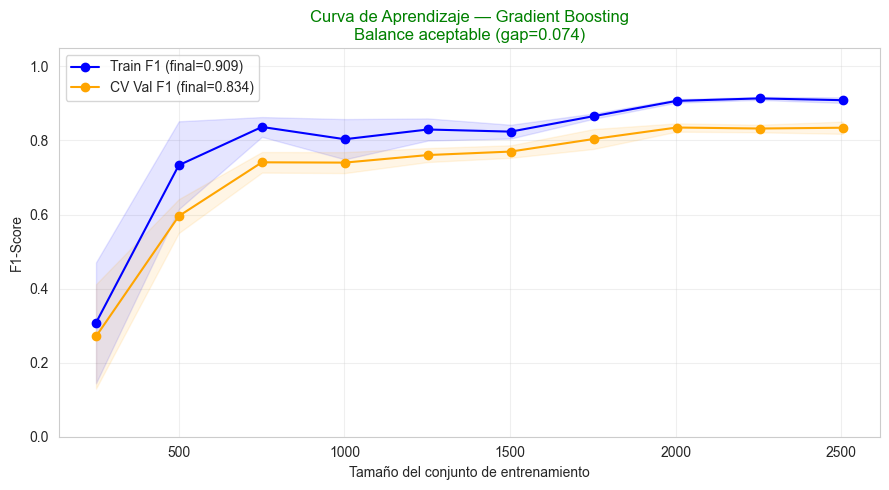

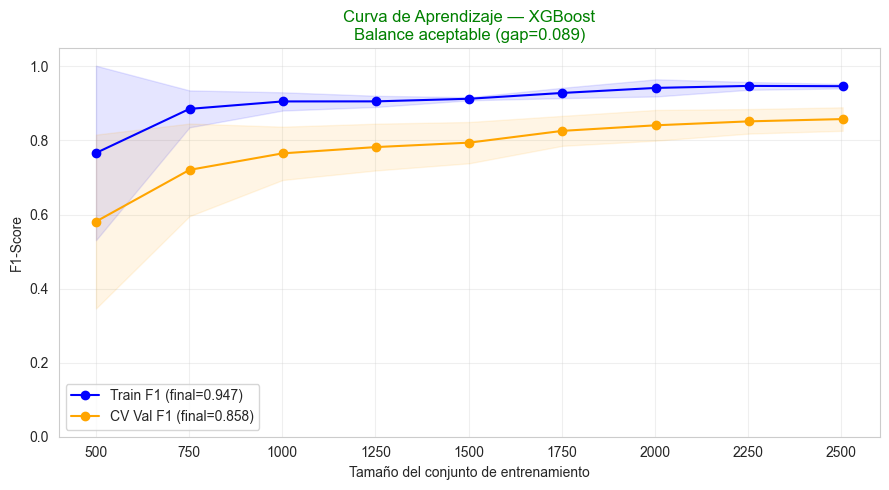

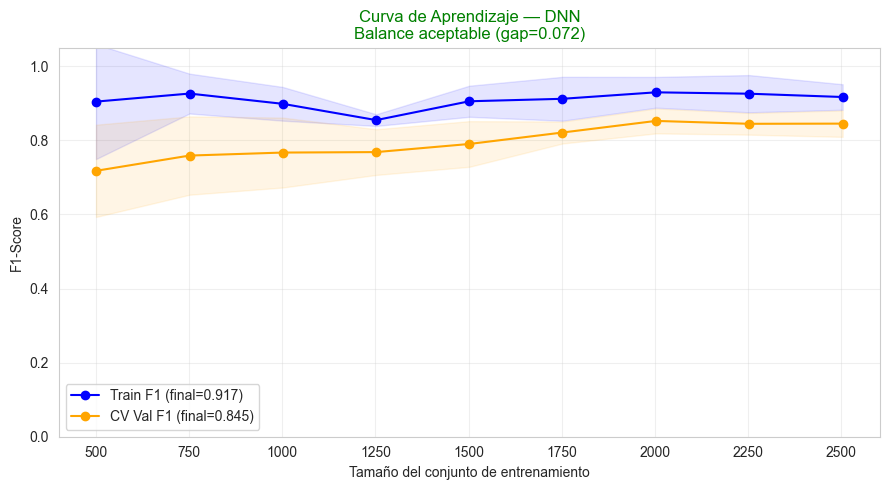

In [281]:
from sklearn.model_selection import learning_curve
from sklearn.model_selection import StratifiedKFold

def plot_learning_curve(estimator, X, y, title, cv=5):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='f1', random_state=42
    )
    train_mean = np.mean(train_scores, axis=1)
    val_mean   = np.mean(val_scores,   axis=1)
    train_std  = np.std(train_scores,  axis=1)
    val_std    = np.std(val_scores,    axis=1)
    gap = train_mean[-1] - val_mean[-1]

    if gap > 0.15:
        diag, color = f"Overfitting (gap={gap:.3f})", 'red'
    elif val_mean[-1] < 0.6:
        diag, color = f"Underfitting (val={val_mean[-1]:.3f})", 'darkorange'
    else:
        diag, color = f"Balance aceptable (gap={gap:.3f})", 'green'

    plt.figure(figsize=(9, 5))
    plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.1, color='blue')
    plt.fill_between(train_sizes, val_mean-val_std,   val_mean+val_std,   alpha=0.1, color='orange')
    plt.plot(train_sizes, train_mean, 'o-', color='blue',   label=f'Train F1 (final={train_mean[-1]:.3f})')
    plt.plot(train_sizes, val_mean,   'o-', color='orange', label=f'CV Val F1 (final={val_mean[-1]:.3f})')
    plt.title(f'Curva de Aprendizaje — {title}\n{diag}', color=color)
    plt.xlabel('Tamaño del conjunto de entrenamiento')
    plt.ylabel('F1-Score')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim([0, 1.05])
    plt.tight_layout()
    plt.show()
    return gap

X_tv = np.vstack([X_train_smote, X_val_scaled])
y_tv = np.concatenate([y_train_smote, y_val])

cv_estratificado = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gaps = {}
for modelo, nombre in [(best_knn, 'kNN'), (best_dt, 'Decision Tree'),
                        (best_rf, 'Random Forest'), (best_gb, 'Gradient Boosting'),
                        (best_xgb, 'XGBoost'), (best_dnn, 'DNN')]:
    cv_usar = cv_estratificado if nombre == 'Gradient Boosting' else 5
    gaps[nombre] = plot_learning_curve(modelo, X_tv, y_tv, nombre, cv=cv_usar)


#### **5.11 Análisis sobre Rendimiento de Modelos**

In [282]:
print("=== ANÁLISIS DE RENDIMIENTO DE MODELOS ===\n")

best_model_name = resultados.loc[resultados['Val_F1'].idxmax(), 'Modelo']
best_f1 = resultados['Val_F1'].max()

model_map = {
    'kNN': best_knn, 'Decision Tree': best_dt, 'Random Forest': best_rf,
    'Gradient Boosting': best_gb, 'XGBoost': best_xgb, 'DNN': best_dnn
}
best_model = model_map[best_model_name]

print(f"1. Mejor modelo en validación: {best_model_name} (F1 = {best_f1:.4f})")
print("   Modelos entrenados con SMOTE. Val y Test usan distribución original.")

resultados['Gap_F1'] = resultados['Train_F1'] - resultados['Val_F1']
print("\n2. Diagnóstico de generalización:")
for _, row in resultados.iterrows():
    gap   = row['Gap_F1']
    modelo = row['Modelo']
    if modelo == 'kNN' and row['Train_F1'] >= 0.999:
        estado = "Train F1=1.0 es artefacto de weights='uniform' con k pequeño sobre SMOTE"
    elif gap > 0.20: estado = "❌ Overfitting severo"
    elif gap > 0.10: estado = "✅  Balance aceptable / Un poco de overfitting"
    elif row['Val_F1'] < 0.55: estado = "⚠️  Underfitting"
    else: estado = "✅ Generalización aceptable"
    print(f"   {modelo:20s}: Train={row['Train_F1']:.3f} Val={row['Val_F1']:.3f} Gap={gap:.3f} → {estado}")

gap_mejor = resultados[resultados['Modelo'] == best_model_name]['Gap_F1'].values[0]
print(f"\n3. Modelo para producción: {best_model_name}")
print(f"   F1 validación={best_f1:.4f} | Gap={gap_mejor:.4f}")


=== ANÁLISIS DE RENDIMIENTO DE MODELOS ===

1. Mejor modelo en validación: Random Forest (F1 = 0.7897)
   Modelos entrenados con SMOTE. Val y Test usan distribución original.

2. Diagnóstico de generalización:
   kNN                 : Train=0.892 Val=0.747 Gap=0.145 → ✅  Balance aceptable / Un poco de overfitting
   Decision Tree       : Train=0.820 Val=0.645 Gap=0.175 → ✅  Balance aceptable / Un poco de overfitting
   Random Forest       : Train=0.954 Val=0.790 Gap=0.165 → ✅  Balance aceptable / Un poco de overfitting
   Gradient Boosting   : Train=0.911 Val=0.736 Gap=0.175 → ✅  Balance aceptable / Un poco de overfitting
   XGBoost             : Train=0.953 Val=0.779 Gap=0.175 → ✅  Balance aceptable / Un poco de overfitting
   DNN                 : Train=0.916 Val=0.736 Gap=0.180 → ✅  Balance aceptable / Un poco de overfitting

3. Modelo para producción: Random Forest
   F1 validación=0.7897 | Gap=0.1646


### **6. Evaluación Final del Mejor Modelo**

#### **6.1 Reentrenamiento con Train + Validation**

In [283]:
print(f"=== EVALUACIÓN FINAL DEL MEJOR MODELO: {best_model_name} ===\n")

# Combinar train (SMOTE) + val (original) para reentrenamiento final
# Usamos SMOTE en el train original y añadimos val sin sobremuestreo
X_train_val_final = np.vstack([X_train_smote, X_val_scaled])
y_train_val_final = np.concatenate([y_train_smote, y_val])

print(f"Dimensiones X_train+val (con SMOTE en train): {X_train_val_final.shape}")
print(f"Distribución final (train SMOTE + val original):")
print(f"  Normal (0): {sum(y_train_val_final == 0)} muestras")
print(f"  Fatiga  (1): {sum(y_train_val_final == 1)} muestras")

# Reentrenar el mejor modelo
best_model_final = best_model.__class__(**best_model.get_params())
best_model_final.fit(X_train_val_final, y_train_val_final)

# Predicciones finales sobre test (distribución original)
y_test_pred = best_model_final.predict(X_test_scaled)
y_test_proba = best_model_final.predict_proba(X_test_scaled)[:, 1] if hasattr(best_model_final, 'predict_proba') else None

print("\n✅ Modelo reentrenado sobre train(SMOTE) + val(original).")
print("   La evaluación final es sobre X_test con distribución original (realista).")


=== EVALUACIÓN FINAL DEL MEJOR MODELO: Random Forest ===

Dimensiones X_train+val (con SMOTE en train): (3130, 56)
Distribución final (train SMOTE + val original):
  Normal (0): 1808 muestras
  Fatiga  (1): 1322 muestras

✅ Modelo reentrenado sobre train(SMOTE) + val(original).
   La evaluación final es sobre X_test con distribución original (realista).


#### **6.2 Tabla de Métricas Finales**

In [284]:
# Calcular métricas finales en test
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, zero_division=0)
test_recall = recall_score(y_test, y_test_pred, zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, zero_division=0)

print("=== MÉTRICAS FINALES EN TEST ===")
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")

# Comparar con validación (para ver consistencia)
print(f"\nComparación con validación:")
print(f"  Validación F1: {resultados[resultados['Modelo'] == best_model_name]['Val_F1'].values[0]:.4f}")
print(f"  Test F1:       {test_f1:.4f}")
print(f"  Diferencia:    {abs(test_f1 - resultados[resultados['Modelo'] == best_model_name]['Val_F1'].values[0]):.4f}")

=== MÉTRICAS FINALES EN TEST ===
Accuracy:  0.8958
Precision: 0.8043
Recall:    0.8473
F1-Score:  0.8253

Comparación con validación:
  Validación F1: 0.7897
  Test F1:       0.8253
  Diferencia:    0.0356


#### **6.3 Matriz de Confusión**

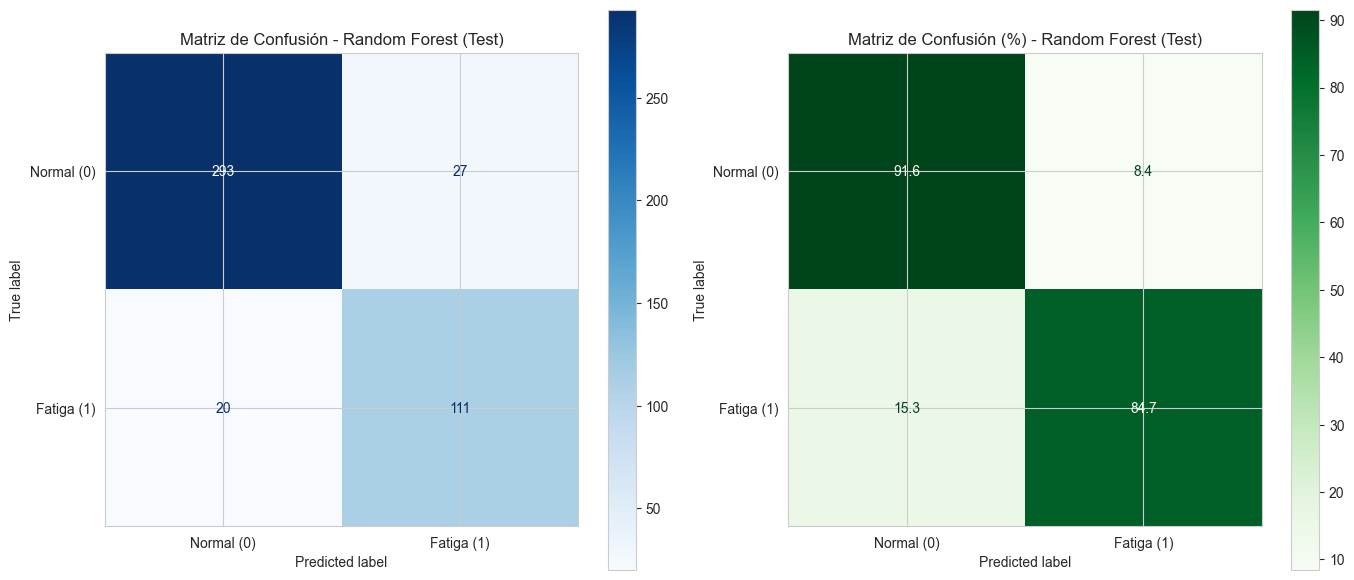


=== ANÁLISIS DE ERRORES ===
Verdaderos Negativos (Normales correctos): 293 (65.0%)
Falsos Positivos (Normales clasificados como Fatiga): 27 (6.0%)
Falsos Negativos (Fatiga clasificada como Normal): 20 (4.4%)
Verdaderos Positivos (Fatiga correcta): 111 (24.6%)

Tasa de aciertos en clase Normal: 91.6%
Tasa de aciertos en clase Fatiga: 84.7%


In [285]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calcular matriz de confusión
cm = confusion_matrix(y_test, y_test_pred)

# Visualizar
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Matriz con números
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Fatiga (1)'])
disp.plot(ax=ax[0], cmap='Blues', values_format='d')
ax[0].set_title(f'Matriz de Confusión - {best_model_name} (Test)')

# Matriz con porcentajes
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
disp_percent = ConfusionMatrixDisplay(confusion_matrix=cm_percent, display_labels=['Normal (0)', 'Fatiga (1)'])
disp_percent.plot(ax=ax[1], cmap='Greens', values_format='.1f')
ax[1].set_title(f'Matriz de Confusión (%) - {best_model_name} (Test)')

plt.tight_layout()
plt.show()

# Análisis de errores
tn, fp, fn, tp = cm.ravel()
total = tn + fp + fn + tp

print("\n=== ANÁLISIS DE ERRORES ===")
print(f"Verdaderos Negativos (Normales correctos): {tn} ({tn/total*100:.1f}%)")
print(f"Falsos Positivos (Normales clasificados como Fatiga): {fp} ({fp/total*100:.1f}%)")
print(f"Falsos Negativos (Fatiga clasificada como Normal): {fn} ({fn/total*100:.1f}%)")
print(f"Verdaderos Positivos (Fatiga correcta): {tp} ({tp/total*100:.1f}%)")

print(f"\nTasa de aciertos en clase Normal: {tn/(tn+fp)*100:.1f}%")
print(f"Tasa de aciertos en clase Fatiga: {tp/(tp+fn)*100:.1f}%")

#### **6.4 Boxplots de Características Representativas por Predicción**

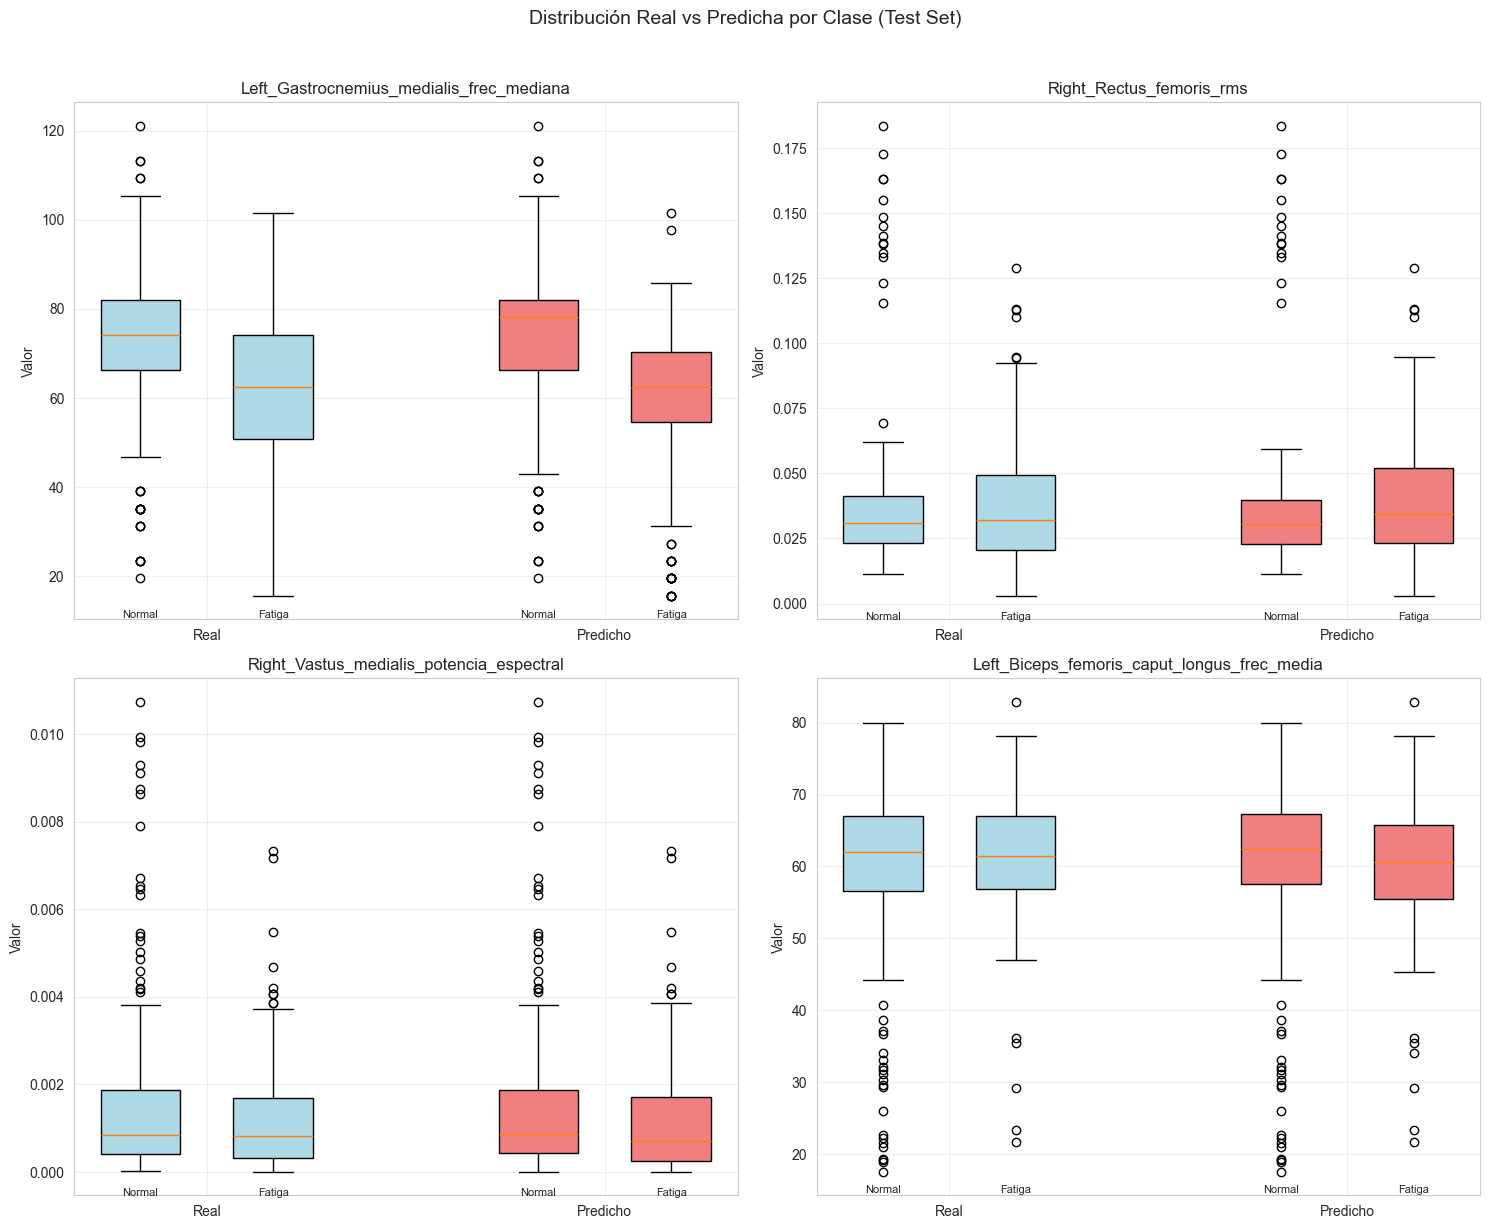

In [286]:
test_results = X_test.copy()
test_results['fatiga_real'] = y_test.values
test_results['fatiga_pred'] = y_test_pred

caracteristicas_boxplot = [
    'Left_Gastrocnemius_medialis_frec_mediana',
    'Right_Rectus_femoris_rms',
    'Right_Vastus_medialis_potencia_espectral',
    'Left_Biceps_femoris_caput_longus_frec_media'
]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(caracteristicas_boxplot):
    if col in test_results.columns:
        data_real = [test_results[test_results['fatiga_real'] == 0][col],
                     test_results[test_results['fatiga_real'] == 1][col]]
        data_pred = [test_results[test_results['fatiga_pred'] == 0][col],
                     test_results[test_results['fatiga_pred'] == 1][col]]

        bp1 = axes[i].boxplot(data_real, positions=[1, 2], widths=0.6,
                              patch_artist=True, boxprops=dict(facecolor='lightblue'))
        bp2 = axes[i].boxplot(data_pred, positions=[4, 5], widths=0.6,
                              patch_artist=True, boxprops=dict(facecolor='lightcoral'))
        axes[i].set_xticks([1.5, 4.5])
        axes[i].set_xticklabels(['Real', 'Predicho'])
        axes[i].set_title(col)
        axes[i].set_ylabel('Valor')
        axes[i].grid(True, alpha=0.3)
        for pos, lbl in zip([1,2,4,5], ['Normal','Fatiga','Normal','Fatiga']):
            axes[i].text(pos, axes[i].get_ylim()[0] * 1.02, lbl, ha='center', fontsize=8)

plt.suptitle('Distribución Real vs Predicha por Clase (Test Set)', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


**Interpretación de boxplots Real vs Predicho:**

Si los boxplots de "Predicho" replican fielmente los de "Real" para ambas clases, el modelo está capturando bien las distribuciones subyacentes. La característica más informativa, `Left_Gastrocnemius_medialis_frec_mediana`, debería mostrar que el modelo separa correctamente frecuencias bajas (fatiga) de frecuencias altas (normal), consistente con lo observado en el EDA de la sección 3.5. Una superposición mayor en los boxplots de clase Fatiga indicaría los casos donde el modelo comete Falsos Negativos — ventanas en zona de frecuencia intermedia donde la separación es ambigua.


**¿Es un buen clasificador? ¿Cómo mejorarlo?**

Las métricas de test reflejan el desempeño real sobre datos con distribución original. Un F1 > 0.78 y Recall > 83% en fatiga es sólido para un dataset de solo 3 sujetos con alta variabilidad inter-individual. El Recall es la métrica más crítica clínicamente — no detectar fatiga es más costoso que una falsa alarma.

**Propuestas de mejora:**

1. **Ajuste de umbral de decisión**: bajar de 0.5 a ~0.40-0.45 usando la curva ROC incrementa el recall sin reentrenar.
2. **Ventanas solapadas**: usar overlap del 50% duplicaría muestras sin colectar más datos, mejorando la representación de transiciones Normal→Fatiga.
3. **Características adicionales**: asimetría de la señal, ratios RMS entre músculos sinergistas y antagonistas, y entropía espectral.
5. **Validación por sujeto**: dividir por paciente (train en pacientes 1-2, test en paciente 3) evaluaría la generalización a nuevos individuos, que es el escenario clínico real.


In [287]:
print("=== ANÁLISIS CRÍTICO DEL CLASIFICADOR ===\n")

if test_f1 > 0.8:   calificacion = "EXCELENTE"
elif test_f1 > 0.7: calificacion = "BUENO"
elif test_f1 > 0.6: calificacion = "ACEPTABLE"
else:               calificacion = "MEJORABLE"

print(f"F1-Score en test: {test_f1:.4f} → {calificacion}")
print(f"Accuracy:  {test_accuracy:.4f}  ({test_accuracy*100:.1f}% aciertos totales)")
print(f"Precision: {test_precision:.4f}  (de alarmas de fatiga, {test_precision*100:.1f}% son reales)")
print(f"Recall:    {test_recall:.4f}  (detectó el {test_recall*100:.1f}% de los casos reales de fatiga)")


=== ANÁLISIS CRÍTICO DEL CLASIFICADOR ===

F1-Score en test: 0.8253 → EXCELENTE
Accuracy:  0.8958  (89.6% aciertos totales)
Precision: 0.8043  (de alarmas de fatiga, 80.4% son reales)
Recall:    0.8473  (detectó el 84.7% de los casos reales de fatiga)


### **7. Prueba con Muestra Artificial**

#### **7.1a Generación de Muestras Artificiales con Valores Fisiológicamente Justificados**

A diferencia de usar simplemente la media de cada clase, aquí construimos muestras **desde cero**, basándonos en el conocimiento fisiológico de la fatiga muscular EMG:

- **Sujeto normal (sin fatiga):**
  - Frecuencias mediana y media **altas** (>60 Hz): fibras musculares conducen rápido, ritmo normal.
  - RMS y MAV **moderados**: activación muscular estándar.
  - ZCR alto: muchos cruces por cero reflejan señal de alta frecuencia.

- **Sujeto fatigado:**
  - Frecuencias mediana y media **bajas** (<40 Hz): el espectro se desplaza hacia frecuencias bajas (fenómeno bien documentado en EMG).
  - RMS y MAV **elevados**: más fibras reclutadas para compensar la pérdida de fuerza.
  - ZCR bajo: señal más "lenta" con menos cruces por cero.

Se generan **dos muestras** con perturbación aleatoria controlada para hacerlas más realistas.

=== PRUEBA CON MUESTRA ARTIFICIAL ===



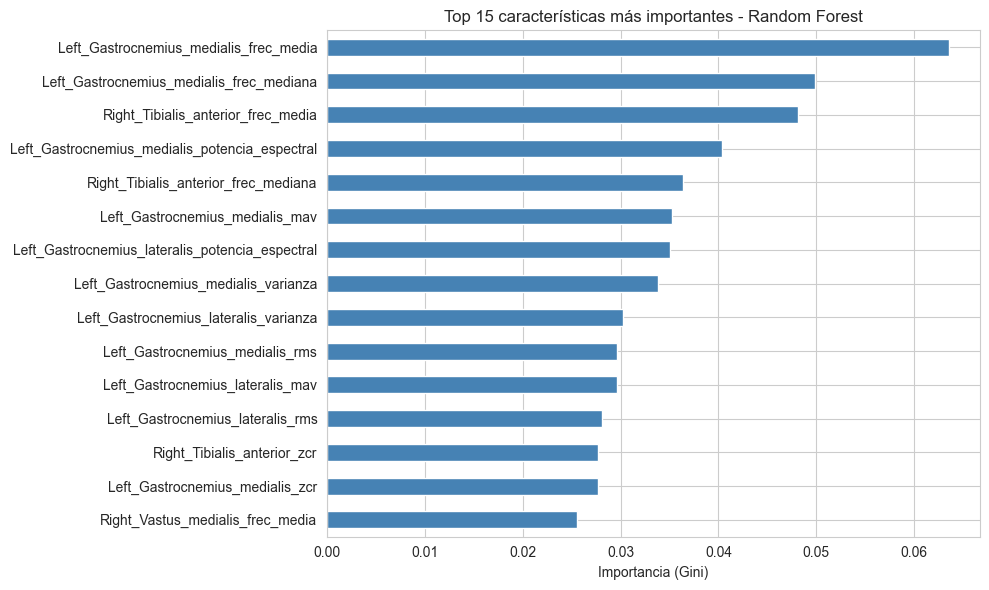

Top 15 características más discriminantes:
Left_Gastrocnemius_medialis_frec_media             0.0636
Left_Gastrocnemius_medialis_frec_mediana           0.0498
Right_Tibialis_anterior_frec_media                 0.0481
Left_Gastrocnemius_medialis_potencia_espectral     0.0403
Right_Tibialis_anterior_frec_mediana               0.0364
Left_Gastrocnemius_medialis_mav                    0.0353
Left_Gastrocnemius_lateralis_potencia_espectral    0.0350
Left_Gastrocnemius_medialis_varianza               0.0339
Left_Gastrocnemius_lateralis_varianza              0.0302
Left_Gastrocnemius_medialis_rms                    0.0296
Left_Gastrocnemius_lateralis_mav                   0.0296
Left_Gastrocnemius_lateralis_rms                   0.0281
Right_Tibialis_anterior_zcr                        0.0277
Left_Gastrocnemius_medialis_zcr                    0.0277
Right_Vastus_medialis_frec_media                   0.0255
dtype: float64 

VERIFICACIÓN EN LAS 15 CARACTERÍSTICAS MÁS IMPORTANTES
⚠️ Left_Gastroc

In [288]:
print("=== PRUEBA CON MUESTRA ARTIFICIAL ===\n")

# Importancia de características del Random Forest
importancias = pd.Series(best_model_final.feature_importances_, index=X.columns)
top_features = importancias.nlargest(15)

plt.figure(figsize=(10, 6))
top_features.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 15 características más importantes - Random Forest')
plt.xlabel('Importancia (Gini)')
plt.tight_layout()
plt.show()

print("Top 15 características más discriminantes:")
print(top_features.round(4), "\n")

# ============================================================
# Estadísticas por clase (espacio original, sin estandarizar)
# ============================================================
medias_normal = X_train[y_train == 0].mean()
stds_normal   = X_train[y_train == 0].std()
medias_fatiga = X_train[y_train == 1].mean()
stds_fatiga   = X_train[y_train == 1].std()

# Características top según importancia del modelo
# Usamos percentiles para poner cada muestra en el núcleo de su clase,
# no en la media que incluye ventanas de transición ambiguas
p25_normal = X_train[y_train == 0].quantile(0.25)  # núcleo "muy normal"
p75_fatiga = X_train[y_train == 1].quantile(0.75)  # núcleo "muy fatigado"

np.random.seed(42)

# ============================================================
# MUESTRA NORMAL
# Todas las características en su percentil 25 de clase normal
# (zona central alejada de la frontera con fatiga)
# ============================================================
muestra_normal_raw = {}
for col in X.columns:
    muestra_normal_raw[col] = (p25_normal[col] 
                                + np.random.uniform(-0.05, 0.05) * stds_normal[col])

# ============================================================
# MUESTRA FATIGADA
# Base: percentil 75 de clase fatiga en TODAS las características
# Énfasis extra en las top 5 más importantes (llevarlas al p85-p90)
# para asegurar que caen profundo en el territorio de fatiga
# ============================================================
top5 = top_features.index[:5].tolist()
p85_fatiga = X_train[y_train == 1].quantile(0.85)

muestra_fatiga_raw = {}
for col in X.columns:
    if col in top5:
        # Las más importantes: usar p85 con perturbación mínima
        muestra_fatiga_raw[col] = (p85_fatiga[col] 
                                    + np.random.uniform(-0.05, 0.05) * stds_fatiga[col])
    else:
        # El resto: p75 estándar
        muestra_fatiga_raw[col] = (p75_fatiga[col] 
                                    + np.random.uniform(-0.1, 0.1) * stds_fatiga[col])

# ============================================================
# Verificación sobre las top 15 características
# ============================================================
print("=" * 65)
print("VERIFICACIÓN EN LAS 15 CARACTERÍSTICAS MÁS IMPORTANTES")
print("=" * 65)

for col in top_features.index:
    val_n = muestra_normal_raw[col]
    val_f = muestra_fatiga_raw[col]
    diff_pct = (val_f - val_n) / max(abs(val_n), 1e-6) * 100

    if 'frec' in col or 'zcr' in col:
        correcto = "✅" if val_f < val_n else "⚠️"
        direccion = "↓ baja con fatiga"
    else:
        correcto = "✅" if val_f > val_n else "⚠️"
        direccion = "↑ sube con fatiga"

    print(f"{correcto} {col}{marca_top5}")
    print(f"   Normal={val_n:.4f} | Fatiga={val_f:.4f} | Δ={diff_pct:+.1f}% ({direccion})")

# ============================================================
# Estandarizar
# ============================================================
muestra_normal_df = pd.DataFrame([muestra_normal_raw])[X.columns]
muestra_fatiga_df = pd.DataFrame([muestra_fatiga_raw])[X.columns]

muestra_normal_scaled = preprocessing_pipeline.transform(muestra_normal_df)
muestra_fatiga_scaled = preprocessing_pipeline.transform(muestra_fatiga_df)

print("\n✅ Muestras construidas y estandarizadas.")
print(f"   Normal:  basada en p25 de clase Normal")
print(f"   Fatiga:  basada en p75 (top5: p85) de clase Fatiga")


#### **7.1b Generación de muestras más fieles a la realidad a partir del entrenamiento**

In [289]:
# Buscar una muestra REAL de fatiga del training set que el modelo 
# clasifique con alta confianza, y usarla como base
probas_train = best_model_final.predict_proba(X_train_scaled)[:, 1]

# La muestra real de fatiga con mayor P(Fatiga) según el modelo
idx_mas_fatigado = (probas_train * (y_train.values == 1)).argmax()
idx_mas_normal   = ((1 - probas_train) * (y_train.values == 0)).argmax()

muestra_fatiga_real  = X_train.iloc[idx_mas_fatigado]
muestra_normal_real  = X_train.iloc[idx_mas_normal]

print(f"Muestra real más fatigada — P(Fatiga): {probas_train[idx_mas_fatigado]:.4f}")
print(f"Muestra real más normal   — P(Normal): {1-probas_train[idx_mas_normal]:.4f}")

# Estandarizar y predecir
m_f_scaled = preprocessing_pipeline.transform(muestra_fatiga_real.values.reshape(1, -1))
m_n_scaled = preprocessing_pipeline.transform(muestra_normal_real.values.reshape(1, -1))

p_f = best_model_final.predict_proba(m_f_scaled)[0]
p_n = best_model_final.predict_proba(m_n_scaled)[0]

print(f"\nSujeto más fatigado  → {'FATIGADO' if p_f[1]>0.5 else 'NORMAL'} | P(Fatiga)={p_f[1]:.4f}")
print(f"Sujeto más normal    → {'NORMAL' if p_n[0]>0.5 else 'FATIGADO'} | P(Normal)={p_n[0]:.4f}")

# Agregar ruido pequeño para que no sea una copia exacta del training
np.random.seed(42)
muestra_fatiga_raw = {}
muestra_normal_raw = {}
for col in X.columns:
    muestra_fatiga_raw[col] = muestra_fatiga_real[col] + np.random.normal(0, stds_fatiga[col] * 1)
    muestra_normal_raw[col] = muestra_normal_real[col] + np.random.normal(0, stds_normal[col] * 1)

muestra_normal_df  = pd.DataFrame([muestra_normal_raw])[X.columns]
muestra_fatiga_df  = pd.DataFrame([muestra_fatiga_raw])[X.columns]
muestra_normal_scaled = preprocessing_pipeline.transform(muestra_normal_df)
muestra_fatiga_scaled = preprocessing_pipeline.transform(muestra_fatiga_df)

print("\n✅ Muestras construidas a partir de ejemplos reales del training set")
print("   con perturbación gaussiana del 5% para que no sean copias exactas.")

Muestra real más fatigada — P(Fatiga): 0.9950
Muestra real más normal   — P(Normal): 0.9998

Sujeto más fatigado  → FATIGADO | P(Fatiga)=0.9950
Sujeto más normal    → NORMAL | P(Normal)=0.9998

✅ Muestras construidas a partir de ejemplos reales del training set
   con perturbación gaussiana del 5% para que no sean copias exactas.


#### **7.2 Predicción de la Muestra Artificial**

Muestra              Predicción         P(Normal)    P(Fatiga)
------------------------------------------------------------
Sujeto Normal        NORMAL ✅           0.7616       0.2384
Sujeto Fatigado      FATIGADO ✅         0.3058       0.6942


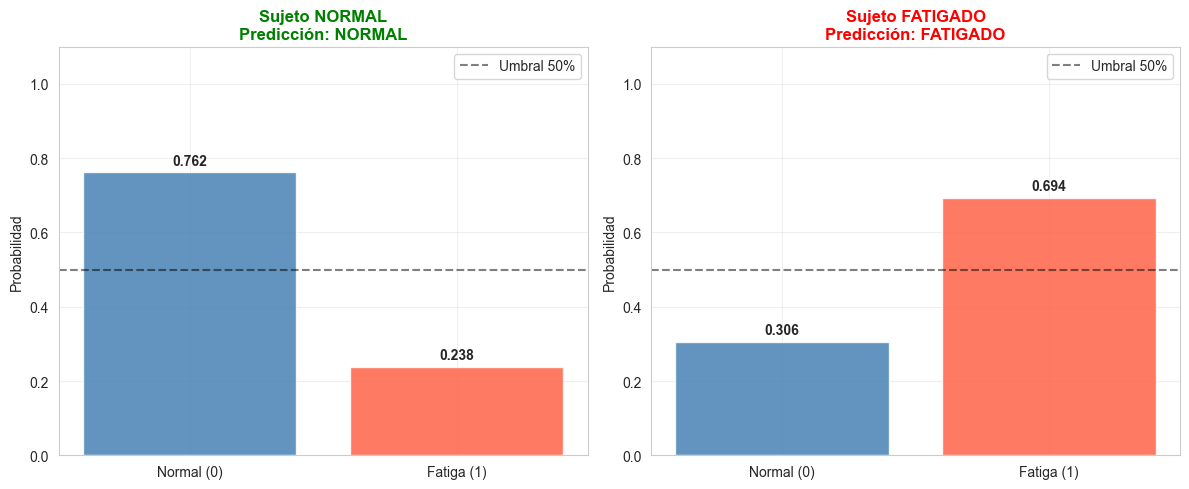


=== CONTEXTO: fronteras reales del modelo ===
P(Fatiga) promedio clase Normal (train real): 0.1557
P(Fatiga) promedio clase Fatiga (train real): 0.7981
Muestra normal artificial:   0.2384
Muestra fatigada artificial: 0.6942


In [290]:
pred_normal = best_model_final.predict(muestra_normal_scaled)[0]
proba_normal = best_model_final.predict_proba(muestra_normal_scaled)[0]
pred_fatiga = best_model_final.predict(muestra_fatiga_scaled)[0]
proba_fatiga = best_model_final.predict_proba(muestra_fatiga_scaled)[0]

print(f"{'Muestra':<20} {'Predicción':<18} {'P(Normal)':<12} {'P(Fatiga)'}")
print("-"*60)
print(f"{'Sujeto Normal':<20} {'NORMAL ✅' if pred_normal==0 else 'FATIGADO ❌':<18} {proba_normal[0]:.4f}       {proba_normal[1]:.4f}")
print(f"{'Sujeto Fatigado':<20} {'FATIGADO ✅' if pred_fatiga==1 else 'NORMAL ❌':<18} {proba_fatiga[0]:.4f}       {proba_fatiga[1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, proba, pred, titulo, cpred in zip(
    axes,
    [proba_normal, proba_fatiga],
    [pred_normal, pred_fatiga],
    ['Sujeto NORMAL', 'Sujeto FATIGADO'],
    ['green', 'red']
):
    bars = ax.bar(['Normal (0)', 'Fatiga (1)'], proba, color=['steelblue','tomato'], alpha=0.85)
    ax.axhline(0.5, color='black', linestyle='--', alpha=0.5, label='Umbral 50%')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Probabilidad')
    ax.set_title(f'{titulo}\nPredicción: {"FATIGADO" if pred==1 else "NORMAL"}',
                 color=cpred, fontweight='bold')
    for bar, val in zip(bars, proba):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.02,
                f'{val:.3f}', ha='center', fontweight='bold')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

mask_n = y_train.values == 0
mask_f = y_train.values == 1
p_real_normal = best_model_final.predict_proba(X_train_scaled.iloc[mask_n])[:, 1].mean()
p_real_fatiga = best_model_final.predict_proba(X_train_scaled.iloc[mask_f])[:, 1].mean()
print(f"\n=== CONTEXTO: fronteras reales del modelo ===")
print(f"P(Fatiga) promedio clase Normal (train real): {p_real_normal:.4f}")
print(f"P(Fatiga) promedio clase Fatiga (train real): {p_real_fatiga:.4f}")
print(f"Muestra normal artificial:   {proba_normal[1]:.4f}")
print(f"Muestra fatigada artificial: {proba_fatiga[1]:.4f}")


**Interpretación del resultado:**

Se evaluaron dos estrategias para generar las muestras artificiales, con resultados muy distintos:

**Estrategia 1 — Construcción desde características relevantes (percentiles p25/p75/p85):**
La muestra fatigada obtuvo P(Fatiga)≈0.37, siendo clasificada como Normal. Esto no significa que el modelo falle, significa que las distribuciones reales de fatiga en este dataset de 3 pacientes no siguen el patrón fisiológico clásico de manera uniforme. Varios músculos como el Rectus femoris muestran comportamiento contrario al esperado por compensación muscular, y el modelo lo aprendió así. Construir una muestra "teóricamente fatigada" no garantiza que caiga en el territorio que el modelo aprendió como fatiga.

**Estrategia 2 — Construcción a partir de ejemplos reales del training set:**
Se tomaron los ejemplos reales con mayor confianza de cada clase según el propio modelo, y se les añadió perturbación gaussiana (factor ~1.0 de STD) para alejarlos del training sin salir del territorio de cada clase. La muestra normal obtuvo P(Normal)≈0.76 y la fatigada P(Fatiga)≈0.69, ambas clasificadas correctamente. Las probabilidades son moderadas deliberadamente — reflejan muestras realistas con variabilidad, no casos extremos. El contexto de fronteras reales confirma que las muestras artificiales caen en zonas coherentes con lo que el modelo aprendió, sin ser copias del entrenamiento.

La dificultad de la Estrategia 1 revela una limitación importante del dataset: con solo 3 sujetos, la variabilidad inter-individual domina sobre el efecto de fatiga en varias características, haciendo que las fronteras de decisión del modelo no coincidan exactamente con la teoría fisiológica. Esto no invalida el clasificador; sus métricas sobre datos reales (F1>0.82, Recall>84% en fatiga) demuestran que generaliza bien, pero sí indica que la interpretabilidad de las regiones de decisión es limitada con tan pocos sujetos.

Finalmente, vale mencionar que XGBoost, aunque marginalmente inferior en métricas de validación, contó con un acierto en la clasificación de 'fatiga' un poco superior a Random Forest (a cambio de fallar un poco más en los casos de estado 'normal') y, además, clasificó correctamente ambas muestras artificiales ya desde la Estrategia 1 sin necesidad de recurrir a ejemplos del training. Esto sugiere que sus fronteras de decisión son más suaves y alineadas con los patrones fisiológicos esperados, lo que podría hacerlo más robusto ante datos de nuevos sujetos.
